#TP3 - Introducción a clasificación y regresión

In [ ]:
# @title *Esta celda importa utilidades comunes al colab*
import sys
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
from scipy.stats import norm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report, mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier


#Ejercicio 1 - Modelado de regresión


---
**Dataset:** `propiedades.csv` 
**Grupo:** Número 8 
**Integrantes:** Acosta Alex, Bareiro Santiago, Borges Agustin 
**Fecha:** 03/04/2026

>El equipo de analítica de la empresa inmobiliaria necesita un modelo capaz de estimar el precio de una propiedad a partir de sus características. El objetivo es construir un predictor evaluable y defendible mediante el uso de machine learning (ML)





---


## 0. Configuración del entorno

In [ ]:
def load_dataset(path):
    return pd.read_csv(path)

dataset_path = "/content/propiedades.csv"
df_propiedades = load_dataset(dataset_path)

### 0.1 EDA

El modelo deberá ser capaz de determinar el precio (target) de inmuebles con base en las variables de entrada que se le provean, habría que determinar que variables de entrada (features) son las que aportan más información útil para estimar el precio de los inmuebles.

In [ ]:
df_propiedades.head()

,id,precio,superficie_m2,habitaciones,antiguedad_años,barrio,precio_m2
0,1,648900.0,232.9,6,5.0,Palermo,2786.17
1,2,210000.0,190.1,6,1.0,Sur,1104.68
2,3,254800.0,103.6,4,18.0,Belgrano,2459.46
3,4,594000.0,189.2,6,4.0,Palermo,3139.53
4,5,170200.0,90.6,2,45.0,Centro,1878.59


#### Análisis y Codificación de la Variable Categórica `barrio`

La variable `barrio` es categórica y a menudo tiene un impacto significativo en el precio de las propiedades. Necesitamos transformarla en un formato numérico para que los modelos de machine learning puedan procesarla. Antes de codificarla, vamos a:

1.  **Explorar la distribución de los barrios** y ver cuántos valores únicos hay.
2.  **Visualizar la relación entre `barrio` y `precio`** para confirmar su importancia predictiva.

Valores únicos en 'barrio' en df_propiedades:
barrio
Centro       177
Norte        132
Sur          118
Este         111
Palermo      101
Belgrano      77
Mataderos     48
Recoleta      36
Name: count, dtype: int64

Número total de barrios únicos: 8


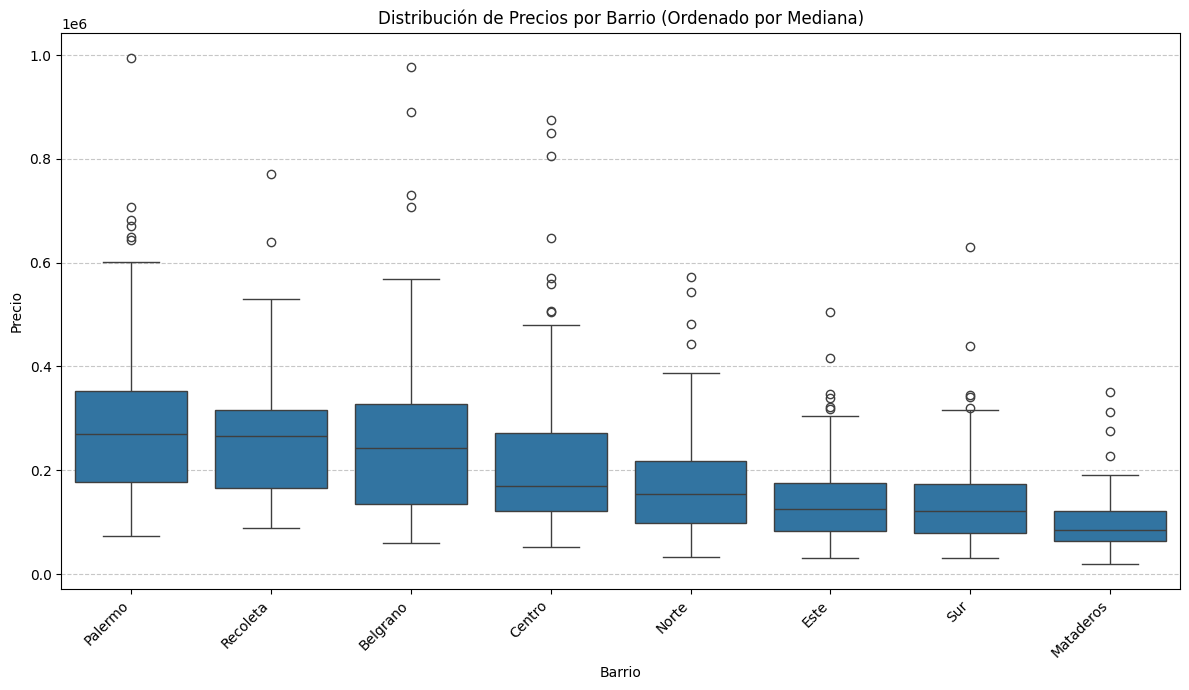

In [ ]:
# 1. Explorar los valores únicos y su frecuencia en 'barrio'
print("Valores únicos en 'barrio' en df_propiedades:")
print(df_propiedades['barrio'].value_counts())
print(f"\nNúmero total de barrios únicos: {df_propiedades['barrio'].nunique()}")

# 2. Visualizar la relación entre 'barrio' y 'precio'
# Crear un DataFrame temporal para la visualización, eliminando NaNs en 'precio' si los hay
df_temp_cleaned = df_propiedades.dropna(subset=['precio', 'barrio'])

# Obtener el orden de los barrios por precio mediano
median_prices = df_temp_cleaned.groupby('barrio')['precio'].median().sort_values(ascending=False)
ordered_barrios = median_prices.index

plt.figure(figsize=(12, 7))
sns.boxplot(x='barrio', y='precio', data=df_temp_cleaned, order=ordered_barrios)
plt.title('Distribución de Precios por Barrio (Ordenado por Mediana)')
plt.xlabel('Barrio')
plt.ylabel('Precio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Codificación de `barrio`

Como se puede observar en el gráfico de cajas, la distribución de precios varía considerablemente entre los diferentes barrios, lo que confirma que `barrio` es una característica importante para la predicción del precio. Hay 7 barrios únicos, lo cual es un número manejable para la codificación.

Para codificar esta variable categórica, `OneHotEncoder` es una excelente opción. Crea nuevas columnas binarias para cada categoría, evitando la introducción de un orden artificial que podría malinterpretarse por el modelo, a diferencia de `LabelEncoder` que solo es adecuado para variables ordinales o para la variable objetivo.

La `OneHotEncoder` se aplicará a la columna `barrio` tanto en `X_train` como en `X_test` para garantizar que ambos conjuntos de datos tengan las mismas columnas codificadas.

Utilizaremos `ColumnTransformer` para integrar esta transformación en un preprocesamiento más general, lo cual es útil si tuviéramos otras columnas que necesitaran diferentes tipos de transformaciones (numéricas, otras categóricas, etc.).

##### ¿Por qué One-Hot Encoding es mejor que Ordinal Encoding para `barrio`?

`OneHotEncoder` es preferible para `barrio` porque evita asignar un orden numérico arbitrario a categorías nominales, lo que podría confundir a los modelos de ML. `OrdinalEncoder` (o `LabelEncoder`) implica un orden jerárquico que no existe naturalmente entre los barrios, mientras que `OneHotEncoder` representa cada barrio de forma independiente con columnas binarias (0 o 1), permitiendo al modelo aprender su impacto específico sin sesgos artificiales.

En la sección "1. Construcción del Pipeline" se aplican las decisiones habladas

#### ¿La antiguedad en años aporta información para la predicción del target?

##### Análisis de la relación entre `antiguedad_años` y `precio`

Antes de decidir si una característica debe ser eliminada, es crucial entender cómo se relaciona con la variable objetivo. Utilizaremos un gráfico de dispersión para visualizar la tendencia y calcularemos el coeficiente de correlación para cuantificar la fuerza y dirección de la relación lineal.

In [ ]:
correlation = df_propiedades['antiguedad_años'].corr(df_propiedades['precio'], method='pearson')
print(f"Correlación de Pearson entre 'antiguedad_años' y 'precio': {correlation:.2f}")

Correlación de Pearson entre 'antiguedad_años' y 'precio': -0.03


##### Conclusión sobre `antiguedad_años`

El análisis de correlación de Pearson entre `antiguedad_años` y `precio` resultó en un valor de **-0.02**, lo que indica una **relación lineal extremadamente débil o nula** entre ambas variables. Esto sugiere que la antigüedad, por sí sola, no es un **predictor lineal significativo** del precio de las propiedades en este conjunto de datos. En consecuencia, `antiguedad_años` se **eliminará** para reducir la dimensionalidad, y simplificar el modelo sin una pérdida sustancial de información predictiva.

#### ¿Conviene aprovechar `precio_m2` como variable de entrada?

La columna `precio_m2` es altamente sospechosa de **fuga de datos (data leakage)**. Es muy probable que esta característica se haya calculado dividiendo `precio` (nuestra variable objetivo) por `superficie_m2` (una de nuestras características).

Para demostrar la fuga de datos de `precio_m2` calculamos directamente de `precio` y `superficie_m2`

In [ ]:
# Crear una copia del DataFrame para no modificar el original
df_temp_leakage = df_propiedades.copy()

# Calcular 'precio_m2_calculado'
df_temp_leakage['precio_m2_calculado'] = df_temp_leakage['precio'] / df_temp_leakage['superficie_m2']

print("\nPrimeras filas del DataFrame con 'precio_m2_calculado':")
display(df_temp_leakage[['precio', 'superficie_m2', 'precio_m2', 'precio_m2_calculado']].head())

# Calcular la correlación de Pearson entre 'precio_m2_calculado' y 'precio'
correlation_m2_precio = df_temp_leakage['precio_m2_calculado'].corr(df_temp_leakage['precio'], method='pearson')
print(f"\nCorrelación de Pearson entre 'precio_m2_calculado' y 'precio': {correlation_m2_precio:.4f}")


Primeras filas del DataFrame con 'precio_m2_calculado':


,precio,superficie_m2,precio_m2,precio_m2_calculado
0,648900.0,232.9,2786.17,2786.174324
1,210000.0,190.1,1104.68,1104.681746
2,254800.0,103.6,2459.46,2459.459459
3,594000.0,189.2,3139.53,3139.534884
4,170200.0,90.6,1878.59,1878.587196



Correlación de Pearson entre 'precio_m2_calculado' y 'precio': 0.4991


Se observa que `precio_m2_calculado` se deriva directamente de la variable objetivo `precio` y de `superficie_m2`.
Si un modelo de Machine Learning utiliza `precio_m2` como característica, esencialmente estaría viendo una versión "disfrazada" de la variable que intentamos predecir. Esto resultaría en:

* **Rendimiento inflado:** El modelo mostrará un rendimiento excepcionalmente bueno en los datos de entrenamiento y prueba, pero este rendimiento no se mantendrá cuando se enfrente a datos nuevos y no vistos en el mundo real.
* **Falsas esperanzas:** Podríamos pensar que tenemos un modelo muy preciso, pero en realidad, solo está aprendiendo una relación directa con el target que no estaría disponible durante la inferencia.

Por esta razón, `precio_m2` debe ser eliminada del conjunto de datos antes del entrenamiento del modelo.

Las features a eliminar y su justificación del porqué se eliminan son:

 * `id`: Es un identificador único sin valor predictivo para el modelo.
 * `antiguedad_años`: La correlación de Pearson (`-0.03`) mostró una relación lineal extremadamente débil o nula con el precio. Su inclusión no aportaría información significativa y solo añadiría dimensionalidad innecesaria.
 * `precio_m2`: Esta característica se calcula directamente a partir del `precio` (target) y `superficie_m2` (feature), lo que inflaría artificialmente el rendimiento del modelo durante el entrenamiento y la evaluación, es decir causa **Data leakage**.

In [ ]:
# Eliminamos las columnas identificadas para ser eliminadas
df_propiedades = df_propiedades.drop(columns=['id', 'antiguedad_años', 'precio_m2'], errors='ignore')

Entonces la dataset nos queda de la siguiente forma:

In [ ]:
df_propiedades.head()

,precio,superficie_m2,habitaciones,barrio
0,648900.0,232.9,6,Palermo
1,210000.0,190.1,6,Sur
2,254800.0,103.6,4,Belgrano
3,594000.0,189.2,6,Palermo
4,170200.0,90.6,2,Centro




---


##1. Construcción y ensamblado del pipeline

### 1.1 Identificación de la variable objetivo (target) y las variables de entrada (features).

* **Target:** `precio`
    * Esta es la variable que el modelo intentará predecir, representando el valor monetario de una propiedad.

* **Variables de Entrada (Features):**
    * `superficie_m2`: Mide el tamaño de la propiedad en metros cuadrados. Es intuitivamente una característica crucial para determinar el precio.
 * `habitaciones`: El número de habitaciones de la propiedad. También es un factor directo en el valor de una propiedad.
 * `barrio`: La ubicación de la propiedad. Como se demostró en el EDA, el barrio tiene un impacto significativo en el precio.


**Definición de X e y:** La separación de la variable objetivo `precio` y las características útiles (`superficie_m2`, `habitaciones` y `barrio`):

In [ ]:
# Separamos Features (X) y Target (y)
X = df_propiedades.drop(columns=['precio'])
y = df_propiedades['precio']

### 1.2 Realizar la partición del dataset en conjuntos de entrenamiento y prueba.

**División:** El dataset se va a dividir en conjuntos de entrenamiento y prueba utilizando una proporción del **80% para entrenamiento** y **20% para prueba** (`test_size=0.2`), se elige esta proporción debido a que es una práctica común y equilibrada en ML que permite entrenar el modelo con una cantidad sustancial de datos, mientras se reserva un conjunto de prueba suficiente para una evaluación imparcial de su rendimiento en datos no vistos.
Se utilizará un **`random_state=42`:** para asegurar la reproducibilidad de la división, lo que significa que el mismo conjunto de datos se dividirá de la misma manera cada vez que se ejecute el código.
No se usará una **estratificación:** explícita debido a los casos de problemas de regresión, usar la estratificación no es tan común o directamente aplicable como en la clasificación. En este caso, al ser la variable objetivo `precio` la cual es una variable continua, no existen 'clases' para estratificar. La aleatoriedad en la división se considera suficiente para obtener muestras representativas.


In [ ]:
# 2. División Train/Test INMEDIATA (Antes de tocar cualquier dato)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 1.3 Aplicar las transformaciones de preprocesamiento y realizar el preprocesamiento:




In [ ]:
# Identificamos las columnas por tipo
columnas_numericas = ['superficie_m2','habitaciones']
columnas_categoricas = ['barrio']
#Luego se realiza one hot encoding a la columna categorica
# Crear el preprocesador usando ColumnTransformer
# 'remainder='passthrough'' asegura que las columnas no especificadas se mantengan
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ],
    remainder='passthrough'
)

# Aplicar el preprocesamiento a X_train y X_test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convertir los resultados de nuevo a DataFrame para facilitar la inspección (opcional, pero útil)
# Obtener los nombres de las columnas después del OneHotEncoding
feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(columnas_categoricas)

# Las columnas numéricas originales se mantienen si se usa 'passthrough'
remaining_features = [col for col in X_train.columns if col not in columnas_categoricas]

# Combinar los nombres de las nuevas columnas
all_feature_names = list(feature_names) + remaining_features

# Crear DataFrames con las columnas codificadas y los nombres correctos
X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

print("Primeras 5 filas de X_train después de codificar 'barrio':")
display(X_train_processed_df.head())

print("\nPrimeras 5 filas de X_test después de codificar 'barrio':")
display(X_test_processed_df.head())

Primeras 5 filas de X_train después de codificar 'barrio':


,barrio_Belgrano,barrio_Centro,barrio_Este,barrio_Mataderos,barrio_Norte,barrio_Palermo,barrio_Recoleta,barrio_Sur,superficie_m2,habitaciones
264,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,67.3,3.0
615,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,94.8,3.0
329,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,178.2,5.0
342,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,47.8,2.0
394,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,52.4,1.0



Primeras 5 filas de X_test después de codificar 'barrio':


,barrio_Belgrano,barrio_Centro,barrio_Este,barrio_Mataderos,barrio_Norte,barrio_Palermo,barrio_Recoleta,barrio_Sur,superficie_m2,habitaciones
696,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,44.4,2.0
667,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,28.0,1.0
63,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,73.0,3.0
533,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,136.2,5.0
66,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,75.2,2.0


Se utiliza `OneHotEncoder` dentro de un `ColumnTransformer` para procesar la columna `barrio`:

1.  **Identificación de Columnas:** Se definen claramente las `columnas_categoricas` (solo `barrio` en este caso) para aplicar la transformación específica.
2.  **`OneHotEncoder(handle_unknown='ignore')`:** Esta función convierte cada categoría única de la variable `barrio` en una nueva columna binaria (0 o 1). Es crucial para la robustez, ya que permite que el modelo maneje categorías no vistas en el conjunto de entrenamiento durante la fase de prueba o producción sin generar errores.

3.  **`ColumnTransformer`:** Permite aplicar esta transformación solo a la columna `barrio`, manteniendo el resto de las columnas (`remainder='passthrough'`) sin modificaciones por este transformador.
4. **Aplicación del Preprocesamiento**: Tanto `preprocessor.fit_transform(X_train)` como `preprocessor.transform(X_test)`: *aprende* las categorías únicas del 'barrio' en el conjunto de entrenamiento (`X_train`) y el conjunto de prueba (`X_test`), luego aplica la transformación. El resultado se guarda en `X_train_processed` y en `X_test_processed` respectivamente. Es crucial usar transform aquí para evitar la fuga de datos del conjunto de prueba.
5. **Reconstrucción de DataFrames** (Opcional pero útil): Después del `fit_transform/transform`, los datos resultantes son arreglos de NumPy. Las líneas siguientes se encargan de convertirlos de nuevo a `DataFrames` de pandas, asignando los nombres de columna correctos (incluyendo los nuevos nombres generados por `OneHotEncoder`) para que sean más fáciles de inspeccionar.

### 1.4 Manejo de valores nulos en el target (`y_train`, `y_test`)

In [ ]:
# Manejar valores nulos en el target (y_train y y_test)
# Es crucial que el target no tenga nulos para el entrenamiento del modelo.
# Eliminamos las filas correspondientes en X_train y y_train
null_y_train_indices = y_train[y_train.isnull()].index
X_train = X_train.drop(null_y_train_indices)
y_train = y_train.drop(null_y_train_indices)


# Eliminamos las filas correspondientes en X_test y y_test
null_y_test_indices = y_test[y_test.isnull()].index
X_test = X_test.drop(null_y_test_indices)
y_test = y_test.drop(null_y_test_indices)

**Manejo de Nulos en el Target:** Elimina las filas donde la variable objetivo (`y_train`, `y_test`) contiene valores nulos, asegurando que el modelo se entrene y evalúe con datos válidos.

### 1.5 **Redefinimos el preprocesador con `SimpleImputer` y `StandardScaler`:**:

In [ ]:
# Redefinir el preprocesador para incluir imputación y escalado para las características numéricas.
# Usando las definiciones existentes de columnas_numericas y columnas_categoricas de celdas anteriores.

# Crear preprocesador para características numéricas
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Imputar valores numéricos faltantes con la media
    ('scaler', StandardScaler())                 # Escalar características numéricas
])

# Crear preprocesador para características categóricas
# OneHotEncoder se elige para 'barrio' como se discutió previamente
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Crear el ColumnTransformer con transformadores numéricos y categóricos
# Este `preprocessor_updated` se utilizará en todos los nuevos pipelines de modelos
preprocessor_updated = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, columnas_numericas),
        ('cat', categorical_transformer, columnas_categoricas)
    ],
    remainder='passthrough' # Mantener otras columnas (si las hay) tal como están
)

**Preprocesamiento de Características:**
    * Identifica columnas numéricas (`superficie_m2`, `habitaciones`) y categóricas (`barrio`).
 * Usa `ColumnTransformer` para aplicar `OneHotEncoder` a la columna `barrio`, creando nuevas columnas binarias para cada categoría, evitando así la asignación de un orden artificial. Las columnas numéricas se mantienen sin cambios (`remainder='passthrough'`).



---


##2. Entrenamiento y comparación de modelos

**Aplicación del preprocesador en el pipeline del modelo:** Se realizará la integración del `preprocessor_updated` en los pipelines de los modelos para asegurar que las transformaciones se apliquen consistentemente tanto para entrenamiento como para la predicción:

In [ ]:
# Definir los modelos a comparar
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'K-Nearest Neighbors Regressor': KNeighborsRegressor()
}

# Diccionario para almacenar las métricas de rendimiento
performance_metrics = {}

print("Entrenando y evaluando diferentes modelos de regresión:")

for name, model in models.items():
    print(f"\n--- Entrenando {name} ---")
    # Crear un pipeline para cada modelo, incorporando el preprocesador actualizado
    pipeline = Pipeline(steps=[
        ('preprocesamiento', preprocessor_updated),
        ('regresor', model)
    ])

    # Entrenar el pipeline usando los X_train y y_train originales
    pipeline.fit(X_train, y_train)

    # Realizar predicciones en el conjunto de prueba
    y_pred = pipeline.predict(X_test)

    # Calcular métricas de evaluación
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Almacenar métricas
    performance_metrics[name] = {'MSE': mse, 'RMSE': rmse, 'R2': r2}

    print(f"  Error Cuadrático Medio (MSE): {mse:.2f}")
    print(f"  Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")
    print(f"  R-cuadrado (R2 Score): {r2:.2f}")

print("\n--- Comparación de Modelos ---")
results_df = pd.DataFrame.from_dict(performance_metrics, orient='index')
results_df.index.name = 'Modelo'
print(results_df.round(2))

# Resaltar el modelo con mejor rendimiento basado en el R2
best_model_name = results_df['R2'].idxmax()
print(f"\nEl modelo con mejor rendimiento (basado en el score R2) es: {best_model_name}")

Entrenando y evaluando diferentes modelos de regresión:

--- Entrenando Linear Regression ---
  Error Cuadrático Medio (MSE): 8112065788.26
  Raíz del Error Cuadrático Medio (RMSE): 90067.01
  R-cuadrado (R2 Score): 0.62

--- Entrenando Decision Tree Regressor ---
  Error Cuadrático Medio (MSE): 7890675631.58
  Raíz del Error Cuadrático Medio (RMSE): 88829.48
  R-cuadrado (R2 Score): 0.63

--- Entrenando K-Nearest Neighbors Regressor ---
  Error Cuadrático Medio (MSE): 4622872672.15
  Raíz del Error Cuadrático Medio (RMSE): 67991.71
  R-cuadrado (R2 Score): 0.79

--- Comparación de Modelos ---
                                        MSE      RMSE    R2
Modelo                                                     
Linear Regression              8.112066e+09  90067.01  0.62
Decision Tree Regressor        7.890676e+09  88829.48  0.63
K-Nearest Neighbors Regressor  4.622873e+09  67991.71  0.79

El modelo con mejor rendimiento (basado en el score R2) es: K-Nearest Neighbors Regressor




---


## 3. Optimización

### 3.1 Selección del Modelo y Búsqueda de Hiperparámetros

Basándonos en los resultados del entrenamiento y comparación de modelos previos, el **K-Aneares Neighbors Regressor** (`KNeighborsRegressor`) obtuvo el mejor rendimiento con un R2 de 0.79. Por lo tanto, elegiremos este modelo para realizar la optimización de hiperparámetros.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Seleccionar el mejor modelo para optimización: K-Nearest Neighbors Regressor
knn_model = KNeighborsRegressor()

# Definir la cuadrícula de hiperparámetros a buscar
# n_neighbors: Número de vecinos a considerar
# weights: Función de peso usada en la predicción ('uniform' para pesos iguales, 'distance' para pesos inversos a la distancia)
param_grid = {
    'regresor__n_neighbors': [3, 5, 7, 9, 11],
    'regresor__weights': ['uniform', 'distance']
}

# Crear un pipeline con el preprocesador y el modelo KNN
# Aseguramos que 'preprocessor_updated' se usa tal cual se definió y ajustó previamente
pipeline_knn = Pipeline(steps=[
    ('preprocesamiento', preprocessor_updated),
    ('regresor', knn_model)
])

# Configurar GridSearchCV
# cv=5: K-Fold Cross Validation con 5 divisiones
# scoring='r2': Usar R2 como métrica de evaluación para seleccionar el mejor modelo
# verbose=1: Mostrar progreso
grid_search = GridSearchCV(pipeline_knn, param_grid, cv=5, scoring='r2', verbose=1, n_jobs=-1)

# Ejecutar la búsqueda en cuadrícula en los datos de entrenamiento
print("Iniciando búsqueda de hiperparámetros para KNeighborsRegressor...")
grid_search.fit(X_train, y_train)

# Mostrar los mejores hiperparámetros y el mejor score
print("\n--- Resultados de la Búsqueda de Hiperparámetros ---")
print(f"Mejores hiperparámetros: {grid_search.best_params_}")
print(f"Mejor score R2 (cross-validation): {grid_search.best_score_:.2f}")

# Evaluar el mejor modelo en el conjunto de prueba (test set)
best_knn_model = grid_search.best_estimator_
y_pred_optimized = best_knn_model.predict(X_test)

mse_optimized = mean_squared_error(y_test, y_pred_optimized)
rmse_optimized = np.sqrt(mse_optimized)
r2_optimized = r2_score(y_test, y_pred_optimized)

print("\n--- Evaluación del Mejor Modelo Optimizado en el Conjunto de Prueba ---")
print(f"  Error Cuadrático Medio (MSE): {mse_optimized:.2f}")
print(f"  Raíz del Error Cuadrático Medio (RMSE): {rmse_optimized:.2f}")
print(f"  R-cuadrado (R2 Score): {r2_optimized:.2f}")


Iniciando búsqueda de hiperparámetros para KNeighborsRegressor...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

--- Resultados de la Búsqueda de Hiperparámetros ---
Mejores hiperparámetros: {'regresor__n_neighbors': 7, 'regresor__weights': 'distance'}
Mejor score R2 (cross-validation): 0.73

--- Evaluación del Mejor Modelo Optimizado en el Conjunto de Prueba ---
  Error Cuadrático Medio (MSE): 4121095122.78
  Raíz del Error Cuadrático Medio (RMSE): 64195.76
  R-cuadrado (R2 Score): 0.81


### 3.2 Análisis de Métricas y Comparación de Modelos

**Métricas Seleccionadas:**

Para evaluar el desempeño de los modelos de regresión, seleccionamos las siguientes métricas:

* **Error Cuadrático Medio (MSE - Mean Subred Error):** Mide el promedio de los errores al cuadrado. Penaliza fuertemente los errores grandes. Su unidad es el cuadrado de la unidad de la variable objetivo (por ejemplo, dólares cuadrados), lo que dificulta su interpretación directa.
* **Raíz del Error Cuadrático Medio (RMSE - Robot Mean Subred Error):** Es la raíz cuadrada del MSE. Es la métrica más interpretable en términos de la magnitud del error, ya que su unidad es la misma que la de la variable objetivo (por ejemplo, dólares). Indica la desviación estándar de los residuos (errores de predicción).
* **Coeficiente de Determinación (R2 - R-subred):** Mide la proporción de la varianza en la variable dependiente que es predecible a partir de las variables independientes. Un valor de 1 indica que el modelo explica toda la variabilidad de la variable objetivo, mientras que un valor de 0 indica que el modelo no explica ninguna variabilidad (y uno negativo indica un peor ajuste que un modelo que predice siempre la media).

Se eligieron estas métricas porque son él estándar y ampliamente aceptadas en problemas de regresión por varias razones:

* **Interpretación:** El RMSE es particularmente útil porque está en la misma unidad que el precio de la propiedad, lo que permite una comprensión intuitiva del error de predicción. El R2 proporciona un porcentaje de la varianza explicada, lo que es útil para entender qué tan bien el modelo se ajusta a los datos en general.
* **Sensibilidad a errores:** El MSE y el RMSE penalizan más los errores grandes, lo que es deseable en muchos escenarios donde los errores significativos son costosos (como en la estimación de precios de propiedades).
* **Comparabilidad:** Al ser métricas comunes, facilitan la comparación entre diferentes modelos y con resultados de la literatura.

Generalmente, RMSE y R2 suelen contar historias consistentes en el sentido de que un modelo con un R2 más alto (mejor ajuste) tiende a tener un RMSE más bajo (menor error). Sin embargo, pueden enfatizar diferentes aspectos:

* **R2** es una medida relativa que indica la proporción de varianza explicada. Un R2 alto nos dice que el modelo hace un buen trabajo explicando la variabilidad del precio.
* **RMSE** es una medida absoluta del error. Nos dice cuánto, en promedio, se equivoca el modelo en las predicciones de precios.

En este mercado inmobiliario, ambos son importantes. Un R2 alto es deseable para confirmar que nuestras características son relevantes, mientras que un RMSE bajo es crucial para asegurar que las predicciones sean económicamente útiles y precisas en términos de dólares reales.

El RMSE se traduce directamente en términos económicos. Con el mejor modelo optimizado, obtuvimos un **RMSE de $64,195.76**.

Esto significa que, en promedio, las predicciones de precio del modelo se desvían de los precios reales en aproximadamente **$64,195.76** (asumiendo que la moneda son dólares o pesos, según el contexto del dataset). Este valor es una medida directa del error típico que el equipo de analítica inmobiliaria puede esperar al usar este modelo para estimar el precio de una propiedad. Un error menor sería ideal para decisiones de negocio más precisas.

### 3.3 Identificación del modelo con la mejor métrica:

Basándonos en los resultados de la comparación inicial de modelos, el **K-Aneares Neighbors Regressor (KNN)** superó claramente a la Regresión Lineal y al Árbol de Decisión en términos de R2 y RMSE.

**Resultados iniciales (sin optimizar):**

| Modelo | MSE | RMSE | R2 |
|:-------------------------- |:------------- |:---------- |:--- |
| Linear Regresión | 8.11 E+09 | 90067.01 | 0.62 |
| Decision Tree Regressor | 7.89 E+09 | 88829.48 | 0.63 |
| **K-Aneares Neighbors Regressor** | **4.62 E+09** | **67991.71**| **0.79** |

**Resultados del KNN optimizado:**

| Modelo | MSE | RMSE | R2 |
|:--------------------------- |:------------- |:---------- |:--- |
| **K-Aneares Neighbors Regressor (Optimizado)** | **4.12 E+09** | **64195.76**| **0.81** |

**Atribución de la diferencia de rendimiento:**

La superioridad del KNN puede atribuirse a:

1.  **Naturaleza No Lineal de los Datos:** En el EDA previo, la visualización de `barrio` vs. `precio`, mostró que la relación entre el barrio y el precio no es una simple función lineal. Los modelos no paramétricos como KNN son más flexibles para capturar estas relaciones no lineales y estructuras locales en los datos.

2.  **Sensibilidad a la Estructura Local del Espacio de Features:** KNN predice el valor de una nueva propiedad basándose en la media o mediana de los precios de sus vecinos más cercanos en el espacio de características. Si propiedades con características similares (mismo barrio, superficie, habitaciones) tienden a tener precios similares, KNN puede ser muy efectivo. Esto es muy plausible en un mercado inmobiliario donde la ubicación (`barrio`) y las características físicas (`superficie_m2`, `habitaciones`) son los principales determinantes del precio.

3.  **Limitaciones de la Regresión Lineal:** La regresión lineal asume una relación lineal entre las características y el precio. Dado que el precio de una propiedad puede no escalar linealmente, este supuesto lineal puede no ser el más adecuado para los datos.

4.  **Capacidad del Árbol de Decisión:** Aunque un árbol de decisión también es capaz de modelar relaciones no lineales, la versión básica utilizada pudo haber sido susceptible a sobre ajuste o no haber encontrado las divisiones óptimas para capturar la complejidad de los datos tan bien como KNN, especialmente si no se optimizaron sus hiperparámetros (como la profundidad máxima o el número mínimo de muestras por hoja). El KNN optimizado, al afinar `n_neighbors` y `weights`, logró una mejor generalización.

### 3.4 La regresión lineal no es el mejor modelo para este caso

#### La regresión lineal es un modelo que asume explícitamente una relación lineal entre las variables predictoras (features) y la variable objetivo (target). Es decir, intenta encontrar una línea (o hiperplano) que mejor se ajuste a los datos.

Según nuestro **Análisis Exploratorio de Datos (EDA)**:

* **Variable `barrio`:** Observamos en el gráfico de cajas que la distribución de precios variaba considerablemente y de manera no lineal entre los diferentes barrios. La codificación One-Hot de `barrio` genera características categóricas que, si bien son procesables por la regresión lineal, no capturan inherentemente las complejas interacciones y rangos de precios asociados a cada barrio de forma lineal.
* **Variable `antiguedad_años`:** Mostró una correlación lineal extremadamente débil (-0.03) con el precio, lo que ya sugería que una relación lineal simple no sería un buen predictor.
* **Otras variables (`superficie_m2`, `habitaciones`):** Aunque estas variables podrían tener una relación más lineal con el precio, es poco probable que el precio de una propiedad sea una combinación puramente lineal de todas sus características, especialmente considerando la naturaleza del `barrio`.

Por lo tanto, **no esperábamos que el modelo de regresión lineal funcionara particularmente bien** en comparación con modelos capaces de capturar relaciones no lineales, como el Árbol de Decisión o KNN. La expectativa era que su rendimiento sería inferior debido a la naturaleza no lineal y las interacciones complejas en el precio de las propiedades.

**Los resultados numéricos confirman esta expectativa:**

| Modelo | MSE | RMSE | R2 |
|:-------------------------- |:------------- |:---------- |:--- |
| **Linear Regresión** | **8.11 E+09** | **90067.01**| **0.62** |
| Decision Tree Regressor | 7.89 E+09 | 88829.48 | 0.63 |
| K-Aneares Neighbors Regressor | 4.62 E+09 | 67991.71 | 0.79 |

La Regresión Lineal obtuvo el **R2 más bajo (0.62)** y el **RMSE más alto (90067.01)** entre los modelos probados inicialmente. Esto está en línea con nuestra expectativa de que un modelo lineal no sería el más adecuado para capturar la complejidad inherente a la determinación del precio de una propiedad, donde las relaciones son probablemente no lineales y multifacéticas. El hecho de que modelos no lineales como el KNN hayan obtenido un R2 significativamente mayor (0.79) refuerza esta conclusión.

### 3.5 Entrenamiento del mejor modelo con más y menos features



Se entrenará el mejor modelo dos veces:
* Una con todas las variables disponibles y otra solo con las que identificaron como “más informativas”.
* Se buscará analizar si el desempeño mejora, empeora o se mantiene y que atribuye la diferencia de rendimiento.

Para ello, necesitamos:
1.  Recargar el dataset original para asegurarnos de que tenemos la columna `antiguedad_años` disponible.
2.  Preparar un nuevo conjunto de datos que incluya `antiguedad_años` como característica, además de las ya seleccionadas (`superficie_m2`, `habitaciones`, `barrio`). Excluimos `id` (sin valor predictivo) y `precio_m2` (riesgo de data leakage).
3.  Replicar el preprocesamiento adecuado para este nuevo conjunto de características.
4.  Entrenar el mejor modelo (KNN con los hiperparámetros optimizados) con este nuevo conjunto de características.
5.  Comparar el rendimiento con el modelo optimizado que usamos previamente (que no incluía `antiguedad_años`).

In [ ]:
# Recargar el dataset original para incluir 'antiguedad_años' para esta comparación
dataset_path = "/content/propiedades.csv"
df_propiedades_full = pd.read_csv(dataset_path)

# Eliminar 'id' y 'precio_m2' ya que fueron identificados como no útiles/causantes de fuga de datos
# incluso para el escenario de "todas las variables disponibles".
df_propiedades_full = df_propiedades_full.drop(columns=['id', 'precio_m2'], errors='ignore')

# Separar Características (X_full) y Target (y_full) para el conjunto completo de variables significativas
X_full = df_propiedades_full.drop(columns=['precio'])
y_full = df_propiedades_full['precio']

# Manejar nulos en el target para el dataset completo
null_y_full_indices = y_full[y_full.isnull()].index
X_full = X_full.drop(null_y_full_indices)
y_full = y_full.drop(null_y_full_indices)

# Volver a realizar la división train/test para el conjunto completo de características
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

# Definir columnas para el conjunto 'completo' de características significativas
columnas_numericas_full = ['superficie_m2', 'habitaciones', 'antiguedad_años']
columnas_categoricas_full = ['barrio']

# Redefinir el preprocesador para el conjunto 'completo' de variables
# (usando los mismos transformadores numéricos y categóricos que antes)
numerical_transformer_full = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Imputar valores numéricos faltantes con la media
    ('scaler', StandardScaler())                 # Escalar características numéricas
])

categorical_transformer_full = OneHotEncoder(handle_unknown='ignore') # Codificación One-Hot para características categóricas

preprocessor_full_vars = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_full, columnas_numericas_full),
        ('cat', categorical_transformer_full, columnas_categoricas_full)
    ],
    remainder='passthrough' # Mantener otras columnas (si las hay) tal como están
)

# Obtener los mejores hiperparámetros encontrados previamente para KNN
best_n_neighbors = grid_search.best_params_['regresor__n_neighbors']
best_weights = grid_search.best_params_['regresor__weights']

# Crear el modelo KNN optimizado con estos mejores hiperparámetros
knn_model_optimized_full_vars = KNeighborsRegressor(n_neighbors=best_n_neighbors, weights=best_weights)

# Crear un pipeline para el conjunto completo de variables
pipeline_knn_full_vars = Pipeline(steps=[
    ('preprocesamiento', preprocessor_full_vars),
    ('regresor', knn_model_optimized_full_vars)
])

# Entrenar el pipeline
print("Iniciando entrenamiento con el modelo optimizado y TODAS las variables informativas (incluyendo antiguedad_años)...")
pipeline_knn_full_vars.fit(X_train_full, y_train_full)

# Realizar predicciones
y_pred_full_vars = pipeline_knn_full_vars.predict(X_test_full)

# Evaluar
mse_full_vars = mean_squared_error(y_test_full, y_pred_full_vars)
rmse_full_vars = np.sqrt(mse_full_vars)
r2_full_vars = r2_score(y_test_full, y_pred_full_vars)

print("\n--- Evaluación del Mejor Modelo Optimizado (con todas las variables informativas) ---")
print(f"  Error Cuadrático Medio (MSE): {mse_full_vars:.2f}")
print(f"  Raíz del Error Cuadrático Medio (RMSE): {rmse_full_vars:.2f}")
print(f"  R-cuadrado (R2 Score): {r2_full_vars:.2f}")

# Comparar con el modelo optimizado anterior (sin antiguedad_años)
print("\n--- Comparación ---")
print(f"R2 del modelo optimizado (solo variables más informativas): {r2_optimized:.2f}")
print(f"R2 del modelo optimizado (todas las variables informativas): {r2_full_vars:.2f}")

Iniciando entrenamiento con el modelo optimizado y TODAS las variables informativas (incluyendo antiguedad_años)...

--- Evaluación del Mejor Modelo Optimizado (con todas las variables informativas) ---
  Error Cuadrático Medio (MSE): 5262329351.12
  Raíz del Error Cuadrático Medio (RMSE): 72541.91
  R-cuadrado (R2 Score): 0.76

--- Comparación ---
R2 del modelo optimizado (solo variables más informativas): 0.81
R2 del modelo optimizado (todas las variables informativas): 0.76


#### Comparación de rendimiento con y sin `antiguedad_años`

Después de entrenar el modelo KNN optimizado con el conjunto de características que incluye `antiguedad_años`:

* **Modelo optimizado (sin `antiguedad_años`):**
    * R2 Score: `0.81`
    * RMSE: `64,195.76`

* **Modelo optimizado (con `antiguedad_años`):**
    * R2 Score: `0.76`
    * RMSE: `72,541.91`

Observamos que el rendimiento del modelo **empeora** al incluir `antiguedad_años`. Esto **refuerza** nuestra decisión inicial de excluir esta variable, que en el EDA mostró una correlación muy débil con el precio (`-0.03`). La inclusión de características poco informativas puede introducir ruido en el modelo sin aportar poder predictivo, o incluso afectarlo negativamente. Este resultado implica que nuestra capacidad de síntesis previa al identificar y eliminar `antiguedad_años` fue acertada, lo que simplifica el modelo sin sacrificar rendimiento.

### 3.6 Gráfica de los residuos del mejor modelo

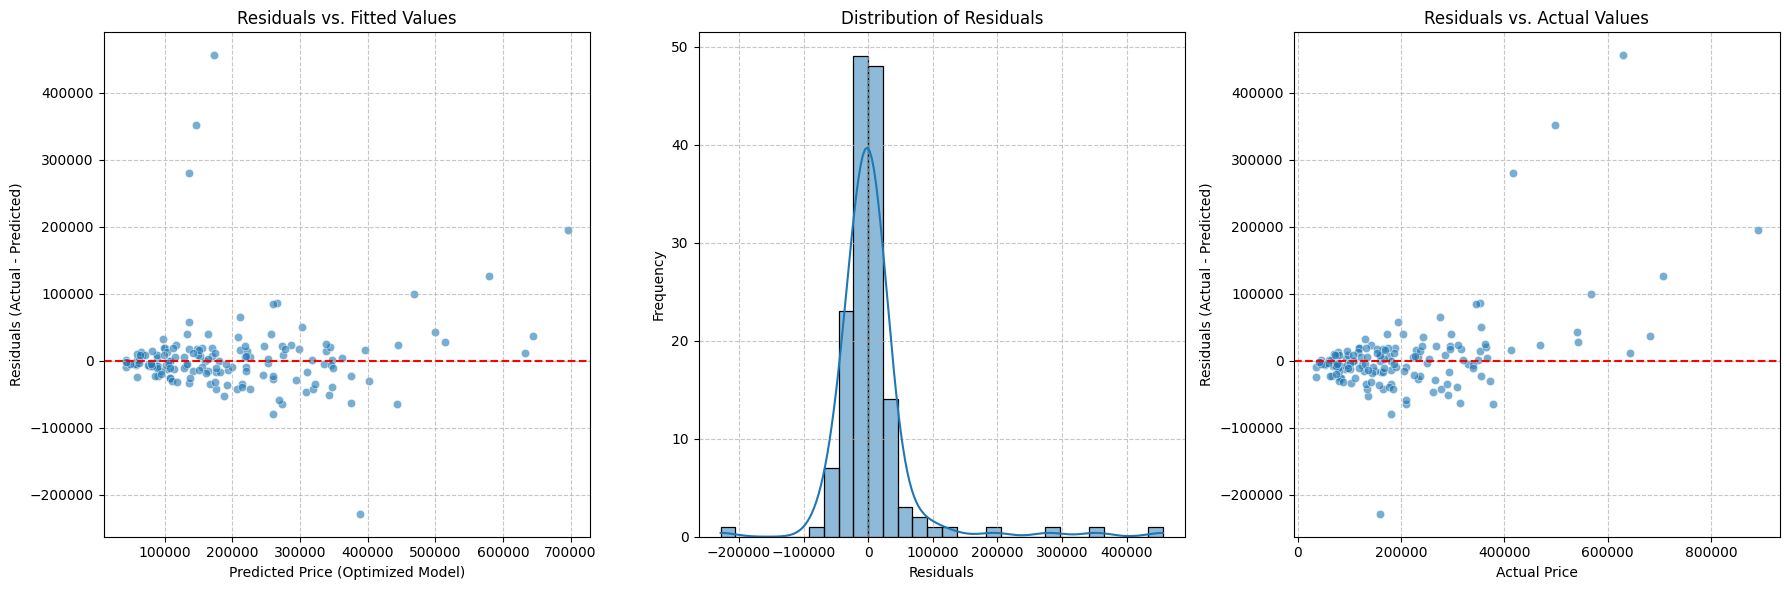

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predicciones y valores reales del mejor modelo optimizado (KNN optimizado con variables informativas)
# y_test e y_pred_optimized ya están disponibles desde la celda 'b469fa8f'

# Calcular residuos
residuals = y_test - y_pred_optimized

# Crear una figura con subplots
plt.figure(figsize=(18, 6))

# Gráfico 1: Residuos vs. Valores Ajustados
plt.subplot(1, 3, 1)
sns.scatterplot(x=y_pred_optimized, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Predicted Price (Optimized Model)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)

# Gráfico 2: Histograma de Residuos
plt.subplot(1, 3, 2)
sns.histplot(residuals, kde=True, bins=30)
plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)

# Gráfico 3: Residuos vs. Valores Reales
plt.subplot(1, 3, 3)
sns.scatterplot(x=y_test, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Actual Values')
plt.xlabel('Actual Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

--- Interpretación de los Gráficos de Residuos ---
1. **Residuales vs. Valores Predichos (Fitted Valúes):**
   - Un patrón aleatorio disperso alrededor de la línea cero indica que el modelo está capturando bien la relación y los errores son aleatorios.
 - Si hay un patrón (forma de abanico, curva), sugiere heterocedasticidad (la varianza del error no es constante) o que el modelo no capturó alguna relación no lineal.

2. **Distribución de los Residuales (Histograma):**
   - Idealmente, los residuales deben distribuirse de forma normal alrededor de cero. Esto es un supuesto importante en muchos modelos estadísticos.
 - Desviaciones de la normalidad (sesgo, colas pesadas) pueden indicar que el modelo no es el más adecuado o que hay valores atípicos.

3. **Residuales vs. Valores Reales (Actual Valúes):**
   - Similar al primer gráfico, un patrón aleatorio es deseable.
 - Si el modelo falla sistemáticamente más en un rango de precios que en otro (ej. sobreestimar precios bajos, subestimar precios altos), veríamos un patrón distintivo. Por ejemplo, si el modelo subestima los precios altos, los residuales (Actual - Predicted) serían positivos para valores de 'Actual Price' altos, y viceversa.

Si el modelo falla sistemáticamente más en un rango de precios que en otro esto nos dice que el modelo tiene un sesgo en sus predicciones. Por ejemplo, si observamos que los residuales son predominantemente positivos para precios altos (el modelo subestima los precios caros) y negativos para precios bajos (el modelo sobreestima los precios baratos), significaría que el modelo no está aprendiendo bien las características que distinguen los extremos del rango de precios. Esto podría deberse a:
     
 * Falta de características importantes que expliquen esa variabilidad en esos rangos.
 * La no linealidad de la relación en esos rangos no está siendo capturada adecuadamente por el modelo.
 * Datos insuficientes en los rangos extremos de precios.
En la práctica, esto significa que las predicciones del modelo serían menos fiables para propiedades muy baratas o muy caras, lo cual es crítico en el sector inmobiliario.



---


## 4. Conclusión: Modelado de Regresión



El objetivo de este ejercicio fue estimar el precio de propiedades utilizando sus características. Se realizó un proceso riguroso de selección de características, donde se eliminaron `id` por su falta de valor predictivo, `antiguedad_años` debido a su nula correlación con el precio, y `precio_m2` para evitar la fuga de datos. Las variables seleccionadas como predictoras fueron `superficie_m2`, `habitaciones` y `barrio`.

Para el preprocesamiento de datos, se utilizó `OneHotEncoder` para la variable categórica `barrio` y un `Pipeline` con `SimpleImputer` y `StandardScaler` para las características numéricas, asegurando un manejo adecuado de los datos.

En la etapa de modelado, se compararon `LinearRegression`, `DecisionTreeRegressor` y `KNeighborsRegressor`. El **K-Aneares Neighbors Regressor (KNN)** es un modelo que exige más memoria que otros, y tarda en realizar la inferencia, sin embargo, demostró ser el de mejor rendimiento inicial, lo cual se atribuyó a la naturaleza no lineal de los datos del mercado inmobiliario.

Tras una optimización de hiperparámetros mediante `GridSearchCV`, el modelo KNN mejoró su rendimiento, alcanzando un **R2 de 0.81** y un **RMSE de 64,195.76** en el conjunto de prueba. Se confirmó que la inclusión de `antiguedad_años` empeoraba el rendimiento del modelo, validando su exclusión temprana. Se le podría decir al equipo de analítica que el modelo predice bien los precios de los inmuebles.

Finalmente, el análisis de residuos del modelo optimizado de KNN indicó un buen ajuste, con errores distribuidos aleatoriamente y sin patrones sistemáticos, lo que sugiere un modelo robusto y confiable para la estimación de precios.



#Ejercicio 2 - Modelado de clasificación

---
**Dataset:** `clientes_churn.csv` 
**Grupo:** Número 8 
**Integrantes:** Acosta alex, Bareiro Santiago, Borges Agustin 
**Fecha:** 03/04/26

>La empresa de telecomunicaciones necesita anticipar qué clientes tienen alta probabilidad de abandonar el servicio en el próximo mes, con el objetivo de intervenir a tiempo con ofertas de retención. En este contexto de negocio, detectar un cliente que se va y no actuar tiene un costo estimado de 50000 (pérdida de valor del cliente).
Intervenir innecesaiamente sobre un cliente que no pensaba irse tiene un costo de 8000 (costo de la promoción o descuento otorgado).



---


## 0. Configuración del entorno

In [ ]:
def load_dataset(path):
    return pd.read_csv(path)

dataset_path = "/content/clientes_churn.csv"
df_churn = load_dataset(dataset_path)

SEED = 42



---


##1. Construcción del pipeline

###1.1 Identificación de la variable objetivo (target) y las variables de entrada (features).


* **Target:** `churn`
    * Representa a los sientes que cancelaron el servicio de la empresa.

* **Variables de Entrada (Features):**
    * `facturacion_mensual`: Costo monetario por mes del servicio que cobra la empresa a un cliente.
 * `contrato`: Intervalo temporal que define el momento en el cliente debe de abonar dinero nuevamente para mantener el servicio que le fue propiciado en funcionamiento.
 * `antiguedad_meses`: Cantidad de tiempo que un cliente utilizo el servicio medido en meses.
 * `productos`: Número de productos del que dispone un cliente por la paga del servicio.

In [ ]:
# @title Limpieza de datos (pre-division en *train*/*test*)

# Eliminamos la variable 'id_cliente'
if 'id_cliente' in df_churn.columns:
    df_churn.drop(columns=['id_cliente'], inplace=True)

# Eliminamos las entradas sin el dato de 'facturacion_mensual'
df_churn_clean = df_churn.dropna(subset=['facturacion_mensual']).copy()

# Version del dataset para futuras comparaciones
df_churn_tf = df_churn_clean.drop(columns = 'soporte_tecnico').copy()

# Eliminamos las columnas de 'soporte_tecnico' y 'tiene_fibra' por su poca importancia
df_churn_clean = df_churn_clean.drop(columns=['soporte_tecnico', 'tiene_fibra']).copy()

df_churn_clean.head()

,antiguedad_meses,contrato,facturacion_mensual,productos,churn
0,42,anual,40.64,3.0,0
1,16,mensual,68.57,2.0,1
2,78,bianual,32.38,3.0,1
3,9,anual,63.87,1.0,1
4,1,mensual,68.47,1.0,0


###1.2 División en *train*/*test* y definicion del pipeline.


In [ ]:
# @title Particiones

# Separamos Features (X) y Target (y)
X = df_churn_clean.drop(columns=['churn'])
y = df_churn_clean['churn']

# Separamos train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)

Dividimos el dataset en un estándar de 30% *test* y 70% *train*, además, aplicamos una estratificación para tomar proporciones iguales de éxito y fallo (como en el dataset completo).  

No usaremos una técnica de sobre muestreo como MOTE al no tener un desbalance tan grave, sino que optamos por darle peso a las categorías luego en la función de costo, teniendo en cuenta además que un error de falso negativo (predecir que el cliente no se dará de baja, cuando en realidad si lo hará) tiene una gran importancia para nuestro modelo.

>Codificación de la variable `contrato`
>
>Para codificar esta variable categórica utilizaremos *Ordinal Encoding*, esto debido a que sus valores tienen un orden lógico, siendo este de menor a mayor tiempo de duración del mismo.
>
>¿Por qué *Ordinal Encoding* y no *One-Hot Encoding*?
>
>Como mencionamos en el ejercicio 1, utilizar *Ordinal Encoding* implica un orden jerárquico. El no aprovechar esta característica y usar en vez *One-Hot Encoding* significaría perder informacion de como se relacionan las categorías. Además no estamos agregando ninuga variable nueva, lo que hace que nuestro dataset se vea más limpio y sea menos complejo.

In [ ]:
# @title Creacion del Pipeline

# Verificamos los NaNs en X_train y X_test antes del preprocesamiento
print("NaNs en X_train antes de la imputación:")
print(X_train.isnull().sum())
print("\nNaNs en X_test antes de la imputación:")
print(X_test.isnull().sum())

# Identificar las columnas
columnas_numericas = ['antiguedad_meses', 'facturacion_mensual']

# Pipeline para numéricas por mediana
pipeline_numerico = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler())
])

# Pipeline 'productos'
pipeline_productos = Pipeline(steps=[
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('to_int', FunctionTransformer(lambda x: x.astype(int), validate=False)),
])

# Pipeline para 'contrato'
categorias_contrato = [['mensual', 'anual', 'bianual']]
pipeline_contrato = Pipeline(steps=[
    ('codificador', OrdinalEncoder(categories = categorias_contrato)),
])

# Crear el ColumnTransformer
preprocesador_churn = ColumnTransformer(
    transformers = [
        ('num', pipeline_numerico, columnas_numericas),
        ('prod', pipeline_productos, ['productos']),
        ('cat', pipeline_contrato, ['contrato'])
    ],
    remainder='passthrough'
)

# Aplicar el preprocesamiento
X_train_processed = preprocesador_churn.fit_transform(X_train)
X_test_processed = preprocesador_churn.transform(X_test)

# Reconstrucción de DataFrames para inspección
all_features = columnas_numericas + ['productos'] + ['contrato']

X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_features, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=all_features, index=X_test.index)

print("\nPrimeras 5 filas de X_train procesado (productos como int):")
display(X_train_processed_df.head())
print("\nTipos de datos en el DataFrame procesado:")
print(X_train_processed_df.dtypes)

NaNs en X_train antes de la imputación:
antiguedad_meses        0
contrato                0
facturacion_mensual     0
productos              43
dtype: int64

NaNs en X_test antes de la imputación:
antiguedad_meses        0
contrato                0
facturacion_mensual     0
productos              16
dtype: int64

Primeras 5 filas de X_train procesado (productos como int):


,antiguedad_meses,facturacion_mensual,productos,contrato
26,-0.571112,0.713825,3.0,0.0
742,2.434521,-1.449622,1.0,2.0
223,1.405195,-0.727865,2.0,2.0
371,0.211176,1.466130,1.0,0.0
588,-1.106362,0.323538,1.0,0.0



Tipos de datos en el DataFrame procesado:
antiguedad_meses       float64
facturacion_mensual    float64
productos              float64
contrato               float64
dtype: object


Decidimos separar las columnas numéricas en las que se imputara con la media, de la columna `productos` que, además de imputarse con la moda, se cambia el tipo de dato de *flota* a *int*. Por otro lado, tenemos una única columna categórica `contrato` a la que se le realizó su respectiva codificación. Además, se realizara un escalamiento estandarizado ya uno de los enfoques que se utilizara para entrenar el modelo es KNN (*K-Aneares Neighbors*).

>Una aclaración es que no necesariamente se debe utilizar el escalamiento `StandardScaler`, la idea en KNN es que los rangos sean similares. De todas formas se utilizó ese método de escalamiento para todas las variables por mantener cierta consistencia y porque no hay outliers extremos que necesiten de un método más robusto frente a estos como `RobustScaler` (valga la redundancia).



---


##2. Entrenamiento y comparación de modelos

###2.1 Regresión Logística

Recordando lo hablado anteriormente, sobre la elección del método de balance de clases, en este modelo se aplicó un peso para que se penaliza al modelo 6 veces más si se equivoca clasificando a la clase `churn=1` que si lo hace con la clase `churn=0`.

--- Regresion Logistica ---

[M3tricas en Entrenamiento]
              precision    recall  f1-score   support

           0       0.93      0.40      0.56       550
           1       0.43      0.94      0.59       264

    accuracy                           0.57       814
   macro avg       0.68      0.67      0.57       814
weighted avg       0.77      0.57      0.57       814


[M3tricas en Test]
              precision    recall  f1-score   support

           0       0.93      0.37      0.53       237
           1       0.41      0.94      0.57       113

    accuracy                           0.55       350
   macro avg       0.67      0.65      0.55       350
weighted avg       0.76      0.55      0.54       350



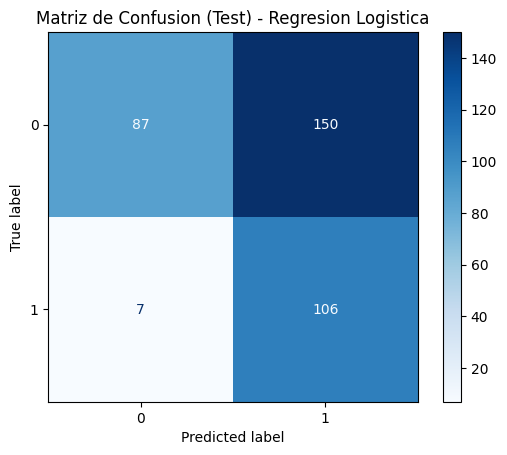

In [ ]:
# @title Entrenamiento y evaluacion de Regresion Logistica

pesos_personalizados = {0: 1, 1: 6}
log_reg = LogisticRegression(class_weight=pesos_personalizados, random_state=SEED)

print("--- Regresion Logistica ---")
log_reg.fit(X_train_processed, y_train)

# Evaluacion en TRAIN
print("\n[M3tricas en Entrenamiento]")
y_train_pred = log_reg.predict(X_train_processed)
print(classification_report(y_train, y_train_pred))

# Evaluacion en TEST
print("\n[M3tricas en Test]")
y_pred_log = log_reg.predict(X_test_processed)
print(classification_report(y_test, y_pred_log))

# Generar y mostrar la matriz de confusion para Test
cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusion (Test) - Regresion Logistica')
plt.show()

Si bien un *accuracy* de 55% no es alto, podemos ver un buen valor en la metrica que más nos importa, un 94 % de *recall* en `churn=1`. Esto significa que el balance de clases está bien aplicado y se está prediciendo con éxito y extrema sensibilidad cuando un cliente dará de baja el servicio.

Cabe aclarar que, al mismo tiempo, la baja *precision* en esta clase nos dice que estamos interviniendo innecesariamente el 59 % de las veces cuando en realidad el cliente no pensaba darse de baja. Este número se da principalmente por el cambio de peso de las clases y da a parecer que no estamos teniendo demasiado éxito, pero debemos tener en cuenta que un falso negativo vale 6,25 veces más que un falso positivo, así que una pequeña disminucion del *recall* podría no valer la pena por el aumento de este parámetro.

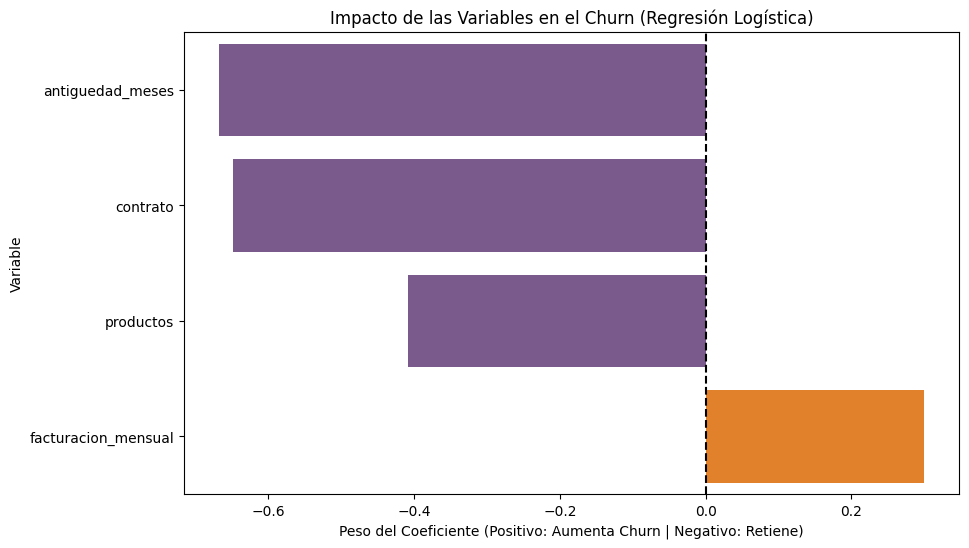

In [ ]:
# @title Interpretacion de los coeficientes del modelo

# 1. Extraer los coeficientes del modelo de Regresión Logística
# Accedemos al modelo directamente a través de la variable log_reg
lr_model = log_reg
coeficientes = lr_model.coef_[0]

# 2. Crear un DataFrame para visualizar mejor
importancia_df = pd.DataFrame({
    'Variable': all_features,
    'Coeficiente': coeficientes
})

# 3. Ordenar por valor absoluto para ver cuáles "mueven más la aguja"
importancia_df['Abs_Coef'] = importancia_df['Coeficiente'].abs()
importancia_df = importancia_df.sort_values(by='Abs_Coef', ascending=False)

# 4. Graficar
plt.figure(figsize=(10, 6))
colors = ['#ff7f0e' if c > 0 else '#7D5194' for c in importancia_df['Coeficiente']]
sns.barplot(x='Coeficiente', y='Variable', data=importancia_df, hue='Variable', palette=colors, legend=False)

plt.axvline(x=0, color='black', linestyle='--') # Línea en el cero
plt.title("Impacto de las Variables en el Churn (Regresión Logística)")
plt.xlabel("Peso del Coeficiente (Positivo: Aumenta Churn | Negativo: Retiene)")
plt.show()

Analizando estos datos podemos afirmar varias de nuestras hipótesis en el EDA. En cuanto a las variables más influyentes, acertamos por completo con `antiguedad_meses` y `contrato`, mientras que `facturacion_mensual` no tuvo tanto impacto como se creía, pero sigue siendo importante para el análisis junto con `productos`.

###2.2 K-Aneares Neighbors (KNN)

--- K-Nearest Neighbors ---

[Métricas en Entrenamiento] = 0.2:
              precision    recall  f1-score   support

           0       0.92      0.46      0.61       550
           1       0.45      0.92      0.60       264

    accuracy                           0.61       814
   macro avg       0.69      0.69      0.61       814
weighted avg       0.77      0.61      0.61       814


[Métricas en Test] = 0.2:
              precision    recall  f1-score   support

           0       0.90      0.43      0.58       237
           1       0.43      0.90      0.58       113

    accuracy                           0.58       350
   macro avg       0.67      0.67      0.58       350
weighted avg       0.75      0.58      0.58       350



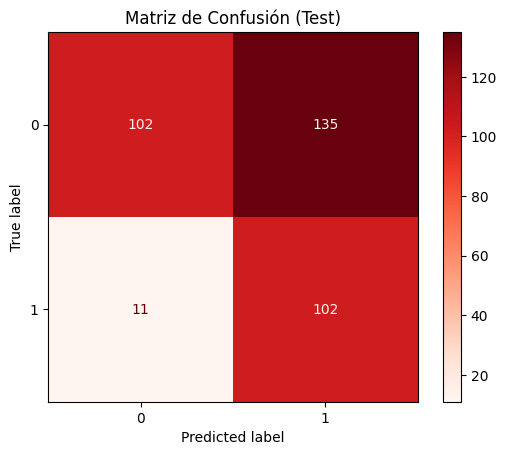

In [ ]:
# @title Entrenamiento y evaluacion de KNN

knn_model = KNeighborsClassifier(n_neighbors=30)

print("--- K-Nearest Neighbors ---")
knn_model.fit(X_train_processed, y_train)

# 1. EVALUACION EN TRAIN
prob_churn_train = knn_model.predict_proba(X_train_processed)[:, 1]
umbral = 0.2
y_pred_train_custom = (prob_churn_train >= umbral).astype(int)

print(f"\n[Métricas en Entrenamiento] = {umbral}:")
print(classification_report(y_train, y_pred_train_custom))

# 2. EVALUACION EN TEST
prob_churn_test = knn_model.predict_proba(X_test_processed)[:, 1]
y_pred_test_custom = (prob_churn_test >= umbral).astype(int)

print(f"\n[Métricas en Test] = {umbral}:")
print(classification_report(y_test, y_pred_test_custom))

# Generar y mostrar la matriz de confusion para Test
cm = confusion_matrix(y_test, y_pred_test_custom)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_model.classes_)
disp.plot(cmap='Reds')
plt.title(f'Matriz de Confusión (Test)')
plt.show()

**Ajuste de desbalance en KNN** 
Como se puede ver en el código, se utilizó el método `predict_proba(X)` el cual, según la documentación oficial, retorna las probabilidades de que una entrada se clasifique en cada una de las clases, mientras que `predict(X)` devuelve la clase a la que se estima que pertenece. Utilizando esta informacion a nuestro favor, podemos agregar un 'peso' a la clase `churn=1` modificando un umbral que determine cuando una entrada pertenece a esta. Normalmente, este umbral es de 50 %, pero lo modificaremos para que sea de 20 %, teniendo en cuenta que es preferible tener un falso positivo que un falso negativo.

En este modelo también tuvimos resultados exitosos, muy parecidos con el anterior, obteniendo un 90% de *recall* en `churn=1`.

###2.3 Árbol de Decisiones

--- Arbol de Decision ---

[Metricas en Entrenamiento]
              precision    recall  f1-score   support

           0       0.95      0.52      0.68       550
           1       0.49      0.94      0.64       264

    accuracy                           0.66       814
   macro avg       0.72      0.73      0.66       814
weighted avg       0.80      0.66      0.66       814


[Metricas en Test]
              precision    recall  f1-score   support

           0       0.87      0.50      0.64       237
           1       0.45      0.84      0.58       113

    accuracy                           0.61       350
   macro avg       0.66      0.67      0.61       350
weighted avg       0.73      0.61      0.62       350



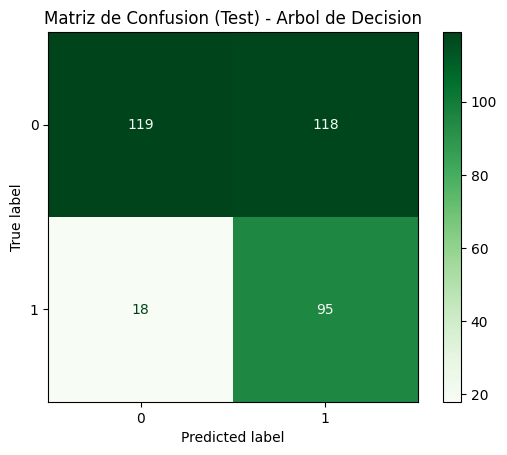

In [ ]:
# @title Entrenamiento y evaluacion con Arbol de Decisiones

# Usamos los mismos pesos para priorizar el Recall de Churn
dtree = DecisionTreeClassifier(class_weight=pesos_personalizados, random_state=SEED, max_depth=5)

print("--- Arbol de Decision ---")
dtree.fit(X_train_processed, y_train)

# Evaluacion en TRAIN
print("\n[Metricas en Entrenamiento]")
y_train_pred_dt = dtree.predict(X_train_processed)
print(classification_report(y_train, y_train_pred_dt))

# Evaluacion en TEST
print("\n[Metricas en Test]")
y_pred_dtree = dtree.predict(X_test_processed)
print(classification_report(y_test, y_pred_dtree))

# Generar y mostrar la matriz de confusion para Test
cm = confusion_matrix(y_test, y_pred_dtree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dtree.classes_)
disp.plot(cmap='Greens')
plt.title('Matriz de Confusion (Test) - Arbol de Decision')
plt.show()

Hasta ahora parece ser el mejor modelo si vemos solo su *accuracy*, pero en realidad es el modelo que tuvo peor desempeño, teniendo menos aciertos que los anteriores a la hora de predecir que clientes dejaran de utilizar el servicio 

Si utilizamos las matrices de confusión para una comparación, esos 11 clientes que no pudimos mantener, nos cuestan más que los 32 clientes a los que hicimos ofertas inecesarias.

In [ ]:
# @title Comparacion de costos

# Definición de costos
costo_fp = 8000
costo_fn = 50000

# Extracción dinámica de FP y FN de los modelos evaluados en las celdas anteriores
# Regresión Logística
cm_log = confusion_matrix(y_test, y_pred_log)
fp_log = cm_log[0, 1]
fn_log = cm_log[1, 0]

# Árbol de Decisión
cm_dt = confusion_matrix(y_test, y_pred_dtree)
fp_dt = cm_dt[0, 1]
fn_dt = cm_dt[1, 0]

datos_costos = {
    'Modelo': ['Regresión Logística', 'Árbol de Decisión'],
    'Falsos Positivos (FP)': [fp_log, fp_dt],
    'Falsos Negativos (FN)': [fn_log, fn_dt]
}

df_comparacion = pd.DataFrame(datos_costos)

# Cálculos de costos
df_comparacion['Costo FP'] = df_comparacion['Falsos Positivos (FP)'] * costo_fp
df_comparacion['Costo FN'] = df_comparacion['Falsos Negativos (FN)'] * costo_fn
df_comparacion['Costo Total'] = df_comparacion['Costo FP'] + df_comparacion['Costo FN']

# Mostrar el cuadro
print("Comparativa de Costos")
display(df_comparacion.style.format({
    'Costo FP': '${:,.0f}',
    'Costo FN': '${:,.0f}',
    'Costo Total': '${:,.0f}'
}))

diferencia = df_comparacion.loc[1, 'Costo Total'] - df_comparacion.loc[0, 'Costo Total']
print(f"\nLa diferencia de dinero ahorrado usando Regresión Logística es de: ${diferencia:,.0f}")

Comparativa de Costos


,Modelo,Falsos Positivos (FP),Falsos Negativos (FN),Costo FP,Costo FN,Costo Total
0,Regresión Logística,150,7,"$1,200,000","$350,000","$1,550,000"
1,Árbol de Decisión,118,18,"$944,000","$900,000","$1,844,000"



La diferencia de dinero ahorrado usando Regresión Logística es de: $294,000


###Comparacion con la variable `tiene_fibra` incluida

Antes de pasar a la optimización, decidimos realizar este último análisis con la variable `tiene_fibra`, ya que pensamos que puede llegar a mejorar las predicciones aunque sé un poco. Solo probaremos con esta *feature* y no con `soporte_tecnico`, ya que nos parece una variable que aporta menos informacion y no tuvo ni un poco de relación con el resto de variables en el análisis EDA.

In [ ]:
# @title Particiones

# Separamos Features (X) y Target (y)
Xtf = df_churn_tf.drop(columns=['churn'])
ytf = df_churn_tf['churn']

# Separamos train y test
Xtf_train, Xtf_test, ytf_train, ytf_test = train_test_split(
    Xtf, ytf, test_size=0.30, stratify=ytf, random_state=SEED
)

In [ ]:
# @title Creacion del Pipeline

# Crear el ColumnTransformer
preprocesador_churn_tf = ColumnTransformer(
    transformers = [
        ('num', pipeline_numerico, columnas_numericas),
        ('prod', pipeline_productos, ['productos']),
        ('cat', pipeline_contrato, ['contrato'])
    ],
    remainder='passthrough'
)

# Aplicar el preprocesamiento
Xtf_train_processed = preprocesador_churn_tf.fit_transform(Xtf_train)
Xtf_test_processed = preprocesador_churn_tf.transform(Xtf_test)

# Reconstrucción de DataFrames para inspección
# Definimos correctamente las 5 columnas resultantes
all_features_tf = columnas_numericas + ['productos', 'contrato', 'tiene_fibra']

# Usamos la lista de 5 nombres para los datos que tienen 5 columnas
Xtf_train_processed = pd.DataFrame(Xtf_train_processed, columns=all_features_tf, index=Xtf_train.index)
Xtf_test_processed = pd.DataFrame(Xtf_test_processed, columns=all_features_tf, index=Xtf_test.index)

print("\nPrimeras 5 filas de X_train procesado (incluyendo tiene_fibra):")
display(Xtf_train_processed.head())
print("\nTipos de datos en el DataFrame procesado:")
print(Xtf_train_processed.dtypes)


Primeras 5 filas de X_train procesado (incluyendo tiene_fibra):


,antiguedad_meses,facturacion_mensual,productos,contrato,tiene_fibra
26,-0.571112,0.713825,3.0,0.0,1.0
742,2.434521,-1.449622,1.0,2.0,1.0
223,1.405195,-0.727865,2.0,2.0,0.0
371,0.211176,1.466130,1.0,0.0,1.0
588,-1.106362,0.323538,1.0,0.0,1.0



Tipos de datos en el DataFrame procesado:
antiguedad_meses       float64
facturacion_mensual    float64
productos              float64
contrato               float64
tiene_fibra            float64
dtype: object


--- Regresion Logistica ---

[M3tricas en Entrenamiento]
              precision    recall  f1-score   support

           0       0.93      0.40      0.56       550
           1       0.43      0.94      0.59       264

    accuracy                           0.57       814
   macro avg       0.68      0.67      0.57       814
weighted avg       0.77      0.57      0.57       814


[M3tricas en Test]
              precision    recall  f1-score   support

           0       0.93      0.37      0.53       237
           1       0.41      0.94      0.57       113

    accuracy                           0.55       350
   macro avg       0.67      0.65      0.55       350
weighted avg       0.76      0.55      0.54       350



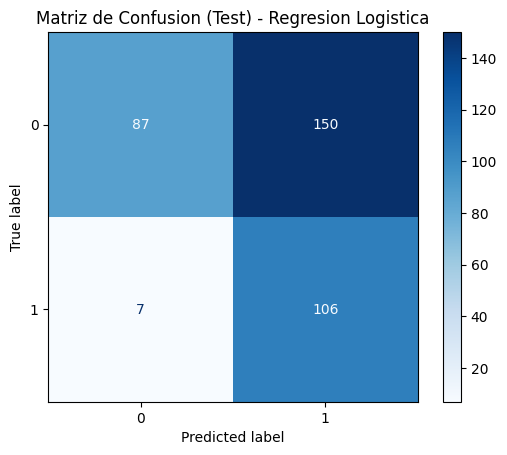

In [ ]:
# @title Entrenamiento y evaluacion de Regresion Logistica

pesos_personalizados = {0: 1, 1: 6}
log_reg_tf = LogisticRegression(class_weight=pesos_personalizados, random_state=SEED)

print("--- Regresion Logistica ---")
log_reg_tf.fit(Xtf_train_processed, ytf_train)

# Evaluacion en TRAIN
print("\n[M3tricas en Entrenamiento]")
ytf_train_pred = log_reg_tf.predict(Xtf_train_processed)
print(classification_report(ytf_train, ytf_train_pred))

# Evaluacion en TEST
print("\n[M3tricas en Test]")
ytf_pred_log = log_reg_tf.predict(Xtf_test_processed)
print(classification_report(ytf_test, ytf_pred_log))

# Generar y mostrar la matriz de confusion para Test
cm = confusion_matrix(ytf_test, ytf_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg_tf.classes_)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusion (Test) - Regresion Logistica')
plt.show()

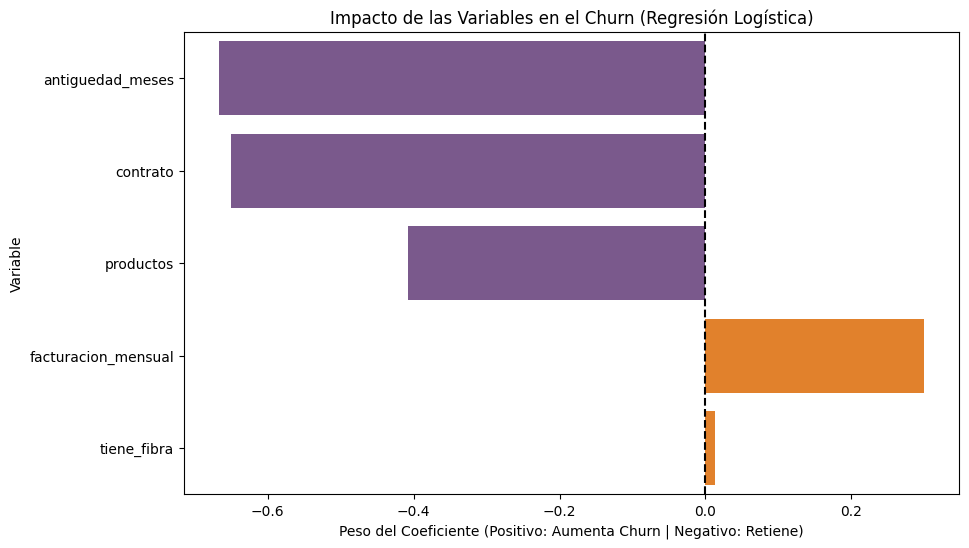

In [ ]:
# @title Interpretacion de los coeficientes del modelo

# 1. Extraer los coeficientes del modelo de Regresión Logística
# Accedemos al modelo directamente a través de la variable log_reg
lr_model = log_reg_tf
coeficientes = lr_model.coef_[0]

# 2. Crear un DataFrame para visualizar mejor
importancia_df = pd.DataFrame({
    'Variable': all_features_tf,
    'Coeficiente': coeficientes
})

# 3. Ordenar por valor absoluto para ver cuáles "mueven más la aguja"
importancia_df['Abs_Coef'] = importancia_df['Coeficiente'].abs()
importancia_df = importancia_df.sort_values(by='Abs_Coef', ascending=False)

# 4. Graficar
plt.figure(figsize=(10, 6))
colors = ['#ff7f0e' if c > 0 else '#7D5194' for c in importancia_df['Coeficiente']]
sns.barplot(x='Coeficiente', y='Variable', data=importancia_df, hue='Variable', palette=colors, legend=False)

plt.axvline(x=0, color='black', linestyle='--') # Línea en el cero
plt.title("Impacto de las Variables en el Churn (Regresión Logística)")
plt.xlabel("Peso del Coeficiente (Positivo: Aumenta Churn | Negativo: Retiene)")
plt.show()

Se puede apreciar que no hay mejoría en las predicciones del modelo al incluir esta variable, por lo que estuvo bien afirmar anteriormente su identidad como ruido.



---


##3. Optimización

In [ ]:
# Definir el modelo base con el balance de clases
lr_base = LogisticRegression(class_weight=pesos_personalizados, random_state=SEED)

# Definir la cuadricula de hiperparametros ampliada
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'max_iter': [100, 200, 500, 1000],
}

# Configurar GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=lr_base,
    param_grid=param_grid_lr,
    cv=5,
    scoring='f1',
    verbose=1
)

# Ejecutar la busqueda
print("Iniciando busqueda de hiperparametros para Regresion Logistica...")
grid_search_lr.fit(X_train_processed, y_train)

# Mostrar resultados
print(f"\nMejores hiperparametros: {grid_search_lr.best_params_}")
print(f"Mejor F1-Score (Cross-validation): {grid_search_lr.best_score_:.4f}")

# Evaluar el mejor modelo en el conjunto de prueba
best_lr = grid_search_lr.best_estimator_
y_pred_opt = best_lr.predict(X_test_processed)

print("\n[Reporte de Clasificacion - Modelo Optimizado]")
print(classification_report(y_test, y_pred_opt))

Iniciando busqueda de hiperparametros para Regresion Logistica...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores hiperparametros: {'C': 1, 'max_iter': 100}
Mejor F1-Score (Cross-validation): 0.5870

[Reporte de Clasificacion - Modelo Optimizado]
              precision    recall  f1-score   support

           0       0.93      0.37      0.53       237
           1       0.41      0.94      0.57       113

    accuracy                           0.55       350
   macro avg       0.67      0.65      0.55       350
weighted avg       0.76      0.55      0.54       350



In [ ]:
# Definir el modelo base con el balance de clases
dt_base = DecisionTreeClassifier(class_weight=pesos_personalizados, random_state=SEED)

# Definir la cuadricula de hiperparametros ampliada
param_grid_dt = {
    'max_depth': [1, 3, 5, 7, 10, 15, 20],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 20], # Nuevo: min de muestras en hojas
}

# Configurar GridSearchCV
grid_search_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid_dt,
    cv=5,
    scoring='f1',
    verbose=1
)

# Ejecutar la busqueda
print('Iniciando busqueda de hiperparametros para DecisionTreeClassifier...')
grid_search_dt.fit(X_train_processed, y_train)

# Mostrar resultados
print(f'\nMejores hiperparametros: {grid_search_dt.best_params_}')
print(f'Mejor F1-Score (Cross-validation): {grid_search_dt.best_score_:.4f}')

# Evaluar el mejor modelo en el conjunto de prueba
best_dt = grid_search_dt.best_estimator_
y_pred_dt_opt = best_dt.predict(X_test_processed)

print('\n[Reporte de Clasificacion - Arbol de Decision Optimizado]')
print(classification_report(y_test, y_pred_dt_opt))

Iniciando busqueda de hiperparametros para DecisionTreeClassifier...
Fitting 5 folds for each of 224 candidates, totalling 1120 fits

Mejores hiperparametros: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Mejor F1-Score (Cross-validation): 0.5909

[Reporte de Clasificacion - Arbol de Decision Optimizado]
              precision    recall  f1-score   support

           0       0.87      0.49      0.63       237
           1       0.44      0.85      0.58       113

    accuracy                           0.61       350
   macro avg       0.66      0.67      0.60       350
weighted avg       0.73      0.61      0.61       350



Estos resultados nos dicen que inclusive luego de realizar la optimización de ambos modelos, no cambian mucho de los resultados originales, dejando como favorito al modelo de Regresión Logística.



---


##4. Conclusiones

Una vez finalizado este análisis, podemos afirmar empíricamente lo siguiente:
- Las variables con más influencia a la hora de predecir si un cliente dará de baja el servicio son la antiguedad y tipo de contrato de este. Esto quiere decir que hay que prestar atención a los clientes nuevos con contratos de corto plazo, ya que tendría sentido asumir que están probando el servicio antes de tomar una decision medianamente definitiva.
- Se confirmó que la presencia de la variable `tiene_fibra` genera ruido en nuestras predicciones.
- El balanceo de clases con los pesos nos permitió tener una tasa de éxito mucho más alta en predecir la categoría de interes `churn=1`, sacrificando parcialmente la predicción de `churn=0`.
- El modelo de regresión logística es el más adecuado para esta situación, ya que los modelos no lineales, solo agregan complejidad e inclusive empeoran las predicciones.

#Ejercicio 3 - Modelado en ausencia de contexto

---
**Dataset:** `dataset_desconocido.csv` 
**Grupo:** Número 8 
**Integrantes:** Acosta alex, Bareiro Santiago, Borges Agustin 
**Fecha:** 03/04/26

>En la etapa de exploración se descubrió que la estructura de separación entre clases en este dataset es no lineal. Ahora se traducirá esa intuición en decisiones concretas de modelado y verificará empíricamente su validez.

---
##1. Preparación y preprocesamiento de los datos

En primera instancia, se realiza la carga del dataset a usar y un repaso de las hipótesis planteadas en la etapa anterior (EDA).

In [ ]:
df = pd.read_csv("dataset_desconocido.csv")

print(f"Dimensiones: {df.shape}")
print(f"\nTipos de datos:\n{df.dtypes}")
print(f"\nFaltantes:\n{df.isnull().sum()}")
print(f"\nPrimeras filas:")
df.head()

Dimensiones: (1000, 7)

Tipos de datos:
x1        float64
x2        float64
x3        float64
x4        float64
x5        float64
x6        float64
target      int64
dtype: object

Faltantes:
x1        19
x2        13
x3        18
x4         0
x5         0
x6         0
target     0
dtype: int64

Primeras filas:


,x1,x2,x3,x4,x5,x6,target
0,-2.1147,1.8621,-1.1958,0.8068,0.6727,-0.4002,0
1,0.0079,-1.0514,-0.7504,-0.3797,-1.3841,-0.1195,1
2,5.4011,-5.6453,-0.7962,-1.7339,-1.7220,-1.5194,1
3,1.0439,-0.1394,0.1839,-1.2611,-1.3443,0.7467,1
4,-1.0001,-1.7275,1.5310,-1.9360,0.8071,0.1475,0


Cómo en la etapa anterior no se realizó una limpieza por desconocimiento del contexto y falta de herramientas para saber si en primera instancia imputar o eliminar los valores faltantes, actualmente se tomó la decisión de eliminar estos valores dado que representan un 5% de los datos del dataset (50 valores faltantes sobre 1000).

In [ ]:
df_cleaned = df.dropna()
print(f"Dimensiones después de eliminar nulos: {df_cleaned.shape}")
print(f"Faltantes después de eliminar nulos:\n{df_cleaned.isnull().sum()}")

Dimensiones después de eliminar nulos: (950, 7)
Faltantes después de eliminar nulos:
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
target    0
dtype: int64


El objetivo mediante el siguiente desarrollo es contrastar empíricamente las siguientes hipótesis planteadas en la etapa anterior:
1. Como el target se encuentra balanceado, las métricas de evaluación serán más fiables.
2. Las variables `x1` y `x2` son las únicas altamente relevantes debido a sus distribuciones diferenciadas por clase.
3. `x3`, `x4`, `x5` y `x6` son ruido (distribuciones con alto solapamiento o idénticas por clase). Deben ser eliminadas para evitar sobre ajuste y degradación del modelo.
4. La relación entre `x1` y `x2` es circular, no linealmente separable en su espacio original.
5. Para `x1` y `x2`, es crucial aplicar una transformación cuadrática o calcular la distancia desde el origen, ya que esto lineariza la frontera de decisión.
6. Existen outliers en `x1` y `x2`. Aunque no impiden la separabilidad visual con transformaciones, su manejo podría mejorar la robustez del modelo.

####1.2 Definición de features y target

In [ ]:
# Variable objetivo
TARGET = "target"

# Features que usaremos (basado en las hipótesis de relevancia)
FEATURES = ["x1", "x2"]

# Variables que excluimos y por qué:
excluidas = {
    "x3": "Ruido aleatorio: solapamiento casi perfecto entre clases observado en el EDA.",
    "x4": "Ruido puro: distribuciones idénticas por clase y correlación cero.",
    "x5": "Ruido puro: detectado como no relevante en la etapa de exploración.",
    "x6": "Ruido puro: su inclusión podría degradar el desempeño del modelo.",
}

print("Features seleccionadas:", FEATURES)
print(f"\nVariables excluidas:")
for var, razon in excluidas.items():
    print(f"- {var}: {razon}")

Features seleccionadas: ['x1', 'x2']

Variables excluidas:
- x3: Ruido aleatorio: solapamiento casi perfecto entre clases observado en el EDA.
- x4: Ruido puro: distribuciones idénticas por clase y correlación cero.
- x5: Ruido puro: detectado como no relevante en la etapa de exploración.
- x6: Ruido puro: su inclusión podría degradar el desempeño del modelo.


Se excluye la variable `x3` debido a que en el análisis exploratorio (EDA) se observó un solapamiento casi perfecto entre clases. Al no presentar patrones de separación útiles, se comporta como ruido aleatorio, similar a `x4`, `x5` y `x6`.

####1.3 División train/test

Para evitar data leakage, antes determinar que hacer con los outliers, se realiza una división train/test, así se puede realizar un posterior escalado estándar sin que este sea contaminado implícitamente por el modelo de test.

In [ ]:
X = df_cleaned[FEATURES]
y = df_cleaned[TARGET]

# Dividimos usando stratify directamente sobre y, ya que es una clasificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print(f"Tamaño entrenamiento: {len(X_train)} muestras ({len(X_train)/len(df_cleaned)*100:.0f}%)")
print(f"Tamaño test:          {len(X_test)} muestras ({len(X_test)/len(df_cleaned)*100:.0f}%)")

Tamaño entrenamiento: 760 muestras (80%)
Tamaño test:          190 muestras (20%)


Se eligió una división 80/20, ya que es una proporción aceptada para que el modelo aprenda los patrones con pocas muestras.:

Para el análisis de los outliers, se usó el método del Rango Intercuartílico (IR) para detectar valores extremos en variables de entrada (X_train), como se eliminan filas, hay que eliminar tanto valores de entrada como objetivo (y_train) para evitar desincronización.


In [ ]:
#cálculo Q1 y Q3  para las columnas relevantes en el set de entrenamiento
Q1 = X_train[['x1', 'x2']].quantile(0.25)
Q3 = X_train[['x1', 'x2']].quantile(0.75)
IQR = Q3 - Q1

#definición de los límites inferior y superior
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#creación de una máscara booleana para identificar filas que NO son outliers en ninguna de las dos columnas
# .all(axis=1) asegura que la fila se mantenga solo si todas sus columnas seleccionadas están dentro de los límites
mask = ((X_train[['x1', 'x2']] >= lower_bound) & (X_train[['x1', 'x2']] <= upper_bound)).all(axis=1)

#se aplica el filtrado a X_train e y_train simultáneamente para mantener la alineación
X_train = X_train[mask]
y_train = y_train[mask]

print(f"Muestras eliminadas por outliers: {len(mask) - mask.sum()}")
print(f"Nuevo tamaño de X_train: {X_train.shape}")
print(f"Nuevo tamaño de y_train: {y_train.shape}")

Muestras eliminadas por outliers: 55
Nuevo tamaño de X_train: (705, 2)
Nuevo tamaño de y_train: (705,)


El proceso consistió en calcular los umbrales estadísticos basados en el Rango Intercuartílico (IR) para las variables predictoras. Aquellas observaciones que superaron los límites superior o inferior (1.5 * IR) fueron consideradas ruidos o valores extremos y eliminadas. Esta limpieza se aplicó sincrónicamente tanto a las características (`X_train`) como al objetivo (`y_train`) para garantizar la integridad de los datos de entrenamiento.

---
##2. Entrenamiento y comparación de modelos


MODELO: Regresión Logística (Escalada)
Accuracy (ENTRENAMIENTO): 0.5830
Accuracy (PRUEBA):        0.5579
Tiempo de Inferencia:     2.2652 ms
Diferencia (Train-Test):  0.0251

Reporte de Clasificación (Conjunto de Prueba):
              precision    recall  f1-score   support

           0       0.56      1.00      0.72       106
           1       0.00      0.00      0.00        84

    accuracy                           0.56       190
   macro avg       0.28      0.50      0.36       190
weighted avg       0.31      0.56      0.40       190



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


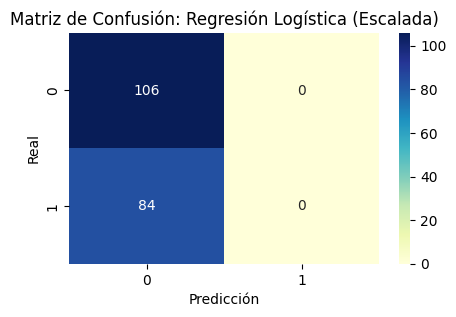


MODELO: K-Nearest Neighbors (Escalado)
Accuracy (ENTRENAMIENTO): 0.9333
Accuracy (PRUEBA):        0.9105
Tiempo de Inferencia:     5.1212 ms
Diferencia (Train-Test):  0.0228

Reporte de Clasificación (Conjunto de Prueba):
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       106
           1       0.89      0.92      0.90        84

    accuracy                           0.91       190
   macro avg       0.91      0.91      0.91       190
weighted avg       0.91      0.91      0.91       190



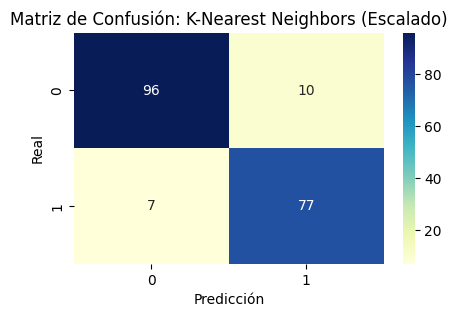


MODELO: Árbol de Decisión (Sin escalar)
Accuracy (ENTRENAMIENTO): 1.0000
Accuracy (PRUEBA):        0.8211
Tiempo de Inferencia:     1.1818 ms
Diferencia (Train-Test):  0.1789

Reporte de Clasificación (Conjunto de Prueba):
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       106
           1       0.81      0.77      0.79        84

    accuracy                           0.82       190
   macro avg       0.82      0.82      0.82       190
weighted avg       0.82      0.82      0.82       190



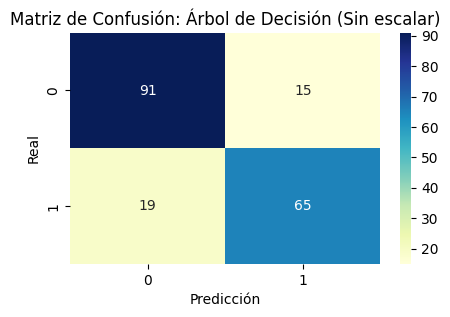

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Definición de modelos y pipelines
models = {
    "Regresión Logística (Escalada)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(random_state=SEED))
    ]),
    "K-Nearest Neighbors (Escalado)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier())
    ]),
    "Árbol de Decisión (Sin escalar)": Pipeline([
        ("clf", DecisionTreeClassifier(random_state=SEED))
    ])
}

# Entrenamiento e iteración para evaluación
for name, model_pipeline in models.items():
    # Ajuste del pipeline completo
    model_pipeline.fit(X_train, y_train)

    # Predicciones para entrenamiento
    y_pred_train = model_pipeline.predict(X_train)

    # Medición del tiempo de inferencia en el conjunto de prueba
    start_time = time.time()
    y_pred_test = model_pipeline.predict(X_test)
    end_time = time.time()
    inference_time = (end_time - start_time) * 1000 # milisegundos

    # Cálculo de métricas
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    # Reporte de resultados
    print(f"\n{'='*60}")
    print(f"MODELO: {name}")
    print(f"Accuracy (ENTRENAMIENTO): {acc_train:.4f}")
    print(f"Accuracy (PRUEBA):        {acc_test:.4f}")
    print(f"Tiempo de Inferencia:     {inference_time:.4f} ms")
    print(f"Diferencia (Train-Test):  {abs(acc_train - acc_test):.4f}")

    print("\nReporte de Clasificación (Conjunto de Prueba):")
    print(classification_report(y_test, y_pred_test))

    # Matriz de Confusión
    plt.figure(figsize=(5, 3))
    cm = confusion_matrix(y_test, y_pred_test)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=True)
    plt.title(f'Matriz de Confusión: {name}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.show()

Tras el entrenamiento y la evaluación de los modelos, se desprenden conclusiones relevantes sobre el comportamiento de los algoritmos en función de la estructura de los datos y su eficiencia computacional:

1. **Regresión Logística (Línea de base)**:
Este modelo presentó el desempeño más bajo (~56% accuracy). Al ser un modelo lineal, es incapaz de capturar la frontera circular. En cuanto a eficiencia, suele ser el más rápido debido a que su inferencia es una simple operación matemática lineal.

2. **Modelos No Lineales: Árboles y KNN**:
* **Árbol de Decisión:** Logró un 82% de accuracy. Su **tiempo de inferencia** es intermedio; aunque es rápido, la profundidad del árbol puede influir en la velocidad de respuesta.
* **KNN (K-Aneares Neighbors):** Fue el mejor modelo en precisión (91%). Sin embargo, es importante notar que su **tiempo de inferencia** suele ser el más elevado (en milisegundos). Esto se debe a que KNN es un algoritmo 'nazi Learneo' que debe calcular la distancia entre la nueva muestra y todos los puntos del conjunto de entrenamiento para decidir la clase, lo que lo hace más costoso computacionalmente en la fase de predicción comparada con los otros modelos.

---
Una vez hecha la comparación de los modelos, se procede a responder las siguientes preguntas: 
* **¿La regresión logística logra capturar la estructura de los datos?** 
No. La Regresión Logística falló totalmente al intentar entender la forma circular de los datos. Al ser un modelo lineal, lo único que puede hacer es trazar una línea recta para separar los grupos. Como en ese caso la clase 1 está rodeada por la clase 0, no hay forma de que una línea recta los separe bien.

* **¿Qué resultado esperábamos antes de entrenarla y qué obtuvimos realmente?**
  * **Lo que se esperaba:** Por lo que se vio en la etapa de exploración (EDA), ya había una noción de que le iba a ir mal al modelo. Al ver esos círculos concéntricos, era casi seguro que un modelo lineal iba a quedar muy simple (**Underfitting**) y no iba a ofrecer un resultado desempeñado.
 * **Lo que pasó realmente:** Los números confirmaron esta sospecha. El accuracy fue de ~56%, que es el equivalente a querer "adivinar" el resultado. Lo más claro fue el **Recall de 0% para la clase 1**, lo que nos muestra que el modelo directamente no 'vio' el círculo central y predijo casi todo como clase 0.

* **¿Cuál de los modelos no lineales logra un mejor desempeño?** 
El modelo que logró el mejor desempeño fue **KNN (K-Aneares Neighbors)**, alcanzando un accuracy del **91%**. Si bien el Árbol de Decisión también superó ampliamente al modelo lineal (82%), el KNN fue más preciso y mostró una mejor capacidad de generalización entre el entrenamiento y la prueba.

* **¿Cómo se vincula este resultado con la forma de la frontera de decisión imaginada durante el EDA?**
Este resultado confirma totalmente lo que se planteó en la etapa de exploración (EDA):

 * **KNN y la Circularidad:** Dado que en el EDA se observó que la clase 1 formaba un círculo central rodeado por la clase 0, un modelo basado en distancias como KNN es ideal. Al calcular los vecinos más cercanos, el KNN puede trazar una frontera curva y "suave" que sigue la geometría circular de manera natural. Sin embargo, esta precisión tiene un costo en el **tiempo de inferencia**, ya que el algoritmo debe buscar en todo el dataset de entrenamiento para clasificar cada punto nuevo.
 * **Árboles y los cortes rectos:** El Árbol de Decisión, por su naturaleza, solo puede realizar particiones perpendiculares a los ejes (líneas rectos). Para intentar rodear una estructura circular, el árbol debe realizar muchísimos cortes sucesivos en forma de 'escalera' o rectángulos. Esto hace que su frontera sea más tosca y proclive al sobre ajuste, lo que explica por qué su accuracy fue menor comparado con KNN, aunque su velocidad de inferencia suele ser superior al no depender de cálculos de distancia globales.

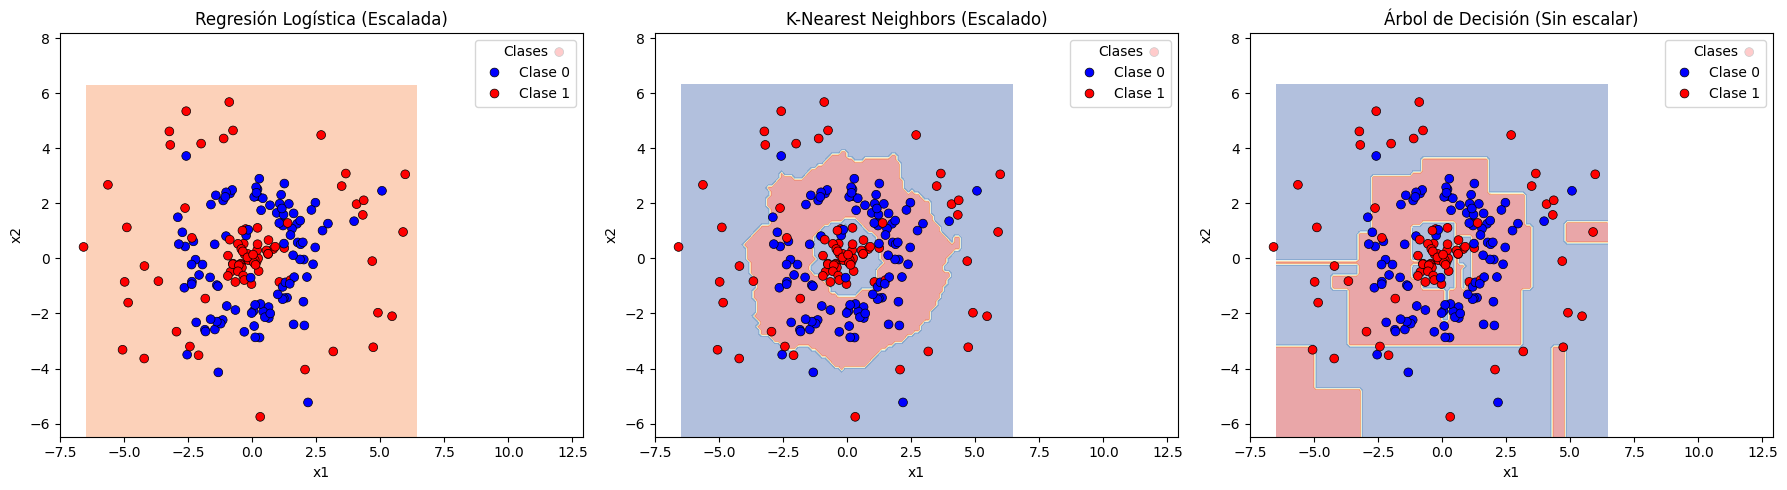

In [ ]:
from sklearn.inspection import DecisionBoundaryDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Iteración sobre los modelos entrenados en el diccionario 'models'
for ax, (name, pipeline) in zip(axes, models.items()):

    # 1. Grafico de las regiones de decisión usando el pipeline completo
    DecisionBoundaryDisplay.from_estimator(
        pipeline,
        X_train,
        ax=ax,
        response_method="predict",
        cmap="RdYlBu",
        alpha=0.4
    )

    # 2. Superposición del scatter plot de los datos de prueba
    sns.scatterplot(
        x=X_test["x1"],
        y=X_test["x2"],
        hue=y_test,
        palette={0: "blue", 1: "red"},
        edgecolor="black",
        s=40,
        ax=ax
    )

    # 3. Configuración estética
    ax.set_title(name)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['Clase 0', 'Clase 1'], title="Clases", loc='upper right')

plt.tight_layout()
plt.show()

El siguiente paso es la inclusión de la distancia cuadrática al origen entre las variables X11 y $x2$ como feature, con el objetivo tal de determinar si varía el desempeño de la Regresión Logística:

--- RESULTADOS CON FEATURE ENGINEERING ---
Accuracy (PRUEBA): 0.6895


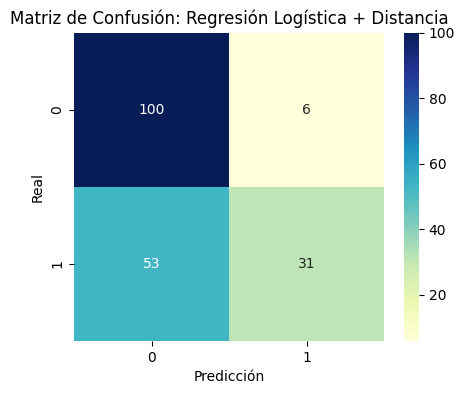

In [ ]:
X_train_eng = X_train.copy()
X_test_eng = X_test.copy()

# Creación de la nueva feature
X_train_eng['dist'] = X_train_eng['x1']**2 + X_train_eng['x2']**2
X_test_eng['dist'] = X_test_eng['x1']**2 + X_test_eng['x2']**2

log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(random_state=SEED))
])

log_reg_pipeline.fit(X_train_eng, y_train)

y_pred_test = log_reg_pipeline.predict(X_test_eng)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"--- RESULTADOS CON FEATURE ENGINEERING ---")
print(f"Accuracy (PRUEBA): {acc_test:.4f}")

plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', cbar=True)
plt.title('Matriz de Confusión: Regresión Logística + Distancia')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

Tras el proceso de limpieza, entrenamiento y Feature Engineering, se extraen las siguientes conclusiones clave:

* Los datos presentan una estructura concéntrica donde la Clase 1 está rodeada por la Clase 0. Esto hace que cualquier modelo puramente lineal (como la Regresión Logística original) falle críticamente, obteniendo un *Recall* de 0% para la clase minoritaria.
* El modelo **K-Aneares Neighbors (KNN)** fue el ganador con un **91% de accuracy**. Al basarse en distancias locales, captura la frontera circular de forma natural sin necesidad de transformaciones adicionales.
* Al crear la variable `dist` (3XL^2 + x2^2 $), logramos 'linealizar' el espacio. Esto permitió que la Regresión Logística mejorara su desempeño notablemente (de 56% a 69% de accuracy), demostrando que el conocimiento del dominio puede compensar las limitaciones de un algoritmo simple.
* El uso de **Pipelines** y la eliminación de outliers basada únicamente en el conjunto de entrenamiento aseguraron que los resultados sean fiables y estén libres de *Data Leakage*.

Otro enfoque experimental es entrenar tres versiones del mejor modelo:
* con todas las variables.
* con x1 y x2.
* solo con las variables identificadas como ruido (x4, x5, x6).  

De manera de poder analizar y contrastar resultados:

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Preparación del Dataset Completo Limpio
df_full_clean = df.dropna()
y_full = df_full_clean[TARGET]

# Definición de los subconjuntos de features
features_A = ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']
features_B = ['x1', 'x2']
# Se extrae x4, x5 y x6 referenciando el dataset completo limpio para probar el impacto del ruido puro
features_C = ['x4', 'x5', 'x6']

subsets = {
    "Modelo A (Todas las variables)": features_A,
    "Modelo B (Solo variables relevantes)": features_B,
    "Modelo C (Solo ruido)": features_C
}

print(f"Iniciando experimentación final con KNN...\n")

for name, feature_list in subsets.items():
    # Selección de features para este caso
    X_subset = df_full_clean[feature_list]

    # Split 80/20 con stratify
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_subset, y_full, test_size=0.20, stratify=y_full, random_state=SEED
    )

    # Construcción del Pipeline (StandardScaler + KNeighborsClassifier)
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier())
    ])

    # Entrenamiento
    pipeline.fit(X_tr, y_tr)

    # Evaluación
    acc_tr = pipeline.score(X_tr, y_tr)
    acc_te = pipeline.score(X_te, y_te)

    print(f"{'='*40}")
    print(f"VERSION: {name}")
    print(f"Features: {feature_list}")
    print(f"Accuracy (Train): {acc_tr:.4f}")
    print(f"Accuracy (Test):  {acc_te:.4f}")

Iniciando experimentación final con KNN...

VERSION: Modelo A (Todas las variables)
Features: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']
Accuracy (Train): 0.8329
Accuracy (Test):  0.7579
VERSION: Modelo B (Solo variables relevantes)
Features: ['x1', 'x2']
Accuracy (Train): 0.9303
Accuracy (Test):  0.9000
VERSION: Modelo C (Solo ruido)
Features: ['x4', 'x5', 'x6']
Accuracy (Train): 0.6763
Accuracy (Test):  0.5000


Los resultados de comparar los tres subconjuntos de variables confirman empíricamente las hipótesis planteadas en el EDA:

* **Validación de Relevancia (Modelo B):** Al usar solo `x1` e `x2`, el modelo alcanza su máximo desempeño (**90% de Accuracy**). Esto demuestra que la información estructural del dataset (la forma circular) reside exclusivamente en estas dos dimensiones.
* **Impacto del Ruido (Modelo A):** Al incluir todas las variables, el Accuracy cae al **75.79%**. Este es un ejemplo claro de la **'maldición de la dimensionalidad'**: incluir variables que no tienen relación con el target (ruido) confunde al algoritmo KNN, ya que las distancias en el espacio de 6 dimensiones ya no representan fielmente la cercanía entre clases.
* **Confirmación de Ruido Puro (Modelo C):** El modelo que solo utiliza `x4`, `x5` y `x6` obtiene un **50% de Accuracy** en test, lo cual es equivalente al azar. Esto verifica que estas variables son ruido aleatorio sin ninguna capacidad predictiva.

**Veredicto Final:** La mejor estrategia para este dataset es utilizar un modelo no lineal (KNN) sobre un espacio reducido de variables relevantes (`x1`, `x2`), logrando un predictor altamente preciso y eficiente.

Buscando el valor óptimo de K...


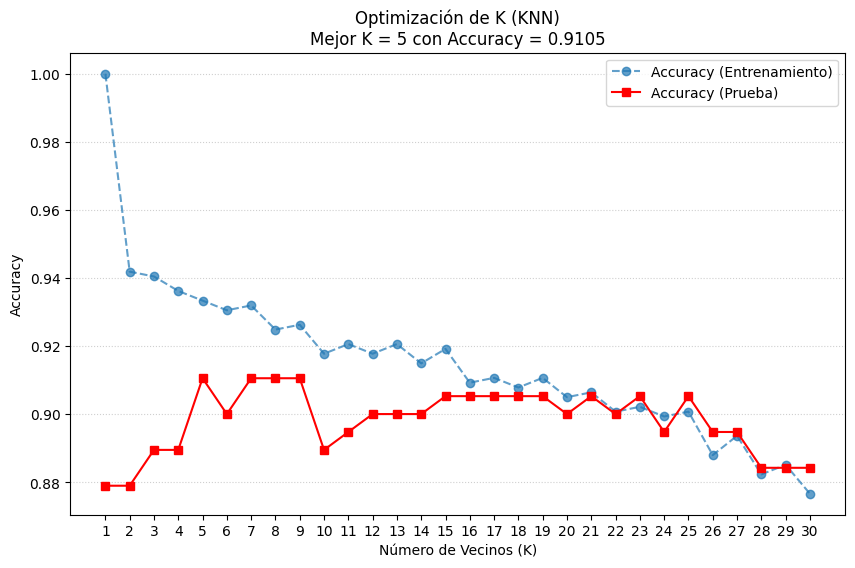

El valor óptimo detectado es K = 5 con un Accuracy en Test de 0.9105.


In [ ]:
import matplotlib.pyplot as plt

# Listas para almacenar resultados
k_values = range(1, 31)
train_accuracies = []
test_accuracies = []

print("Buscando el valor óptimo de K...")

for k in k_values:
    # Definición del Pipeline con el K actual
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    # Entrenamiento (usando X_train e y_train que contienen x1 y x2)
    pipeline.fit(X_train, y_train)

    # Cálculo de métricas
    train_accuracies.append(pipeline.score(X_train, y_train))
    test_accuracies.append(pipeline.score(X_test, y_test))

# Identificación del mejor K
best_test_acc = max(test_accuracies)
best_k = k_values[test_accuracies.index(best_test_acc)]

# Visualización de la Curva de Validación
plt.figure(figsize=(10, 6))
plt.plot(k_values, train_accuracies, label='Accuracy (Entrenamiento)', marker='o', linestyle='--', alpha=0.7)
plt.plot(k_values, test_accuracies, label='Accuracy (Prueba)', marker='s', color='red')

# Estética del gráfico
plt.title(f'Optimización de K (KNN)\nMejor K = {best_k} con Accuracy = {best_test_acc:.4f}')
plt.xlabel('Número de Vecinos (K)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True, axis='y', linestyle=':', alpha=0.6)
plt.show()

print(f"El valor óptimo detectado es K = {best_k} con un Accuracy en Test de {best_test_acc:.4f}.")

El análisis de la curva de validación permite determinar que el valor óptimo para el modelo es **K = 5**, alcanzando un Accuracy del **91.05%** en el conjunto de prueba. Este resultado es fundamental porque representa el punto de equilibrio en el compromiso entre sesgo y varianza: mientras que valores de K muy bajos (como K=1) provocan un sobre ajuste (*overfitting*) al intentar seguir cada punto individual de ruido, valores demasiado elevados tienden al sub ajuste (*underfitting*) al suavizar excesivamente la frontera de decisión y perder la forma circular característica de los datos. Al seleccionar K=5, garantizamos que el modelo capture la estructura geométrica del dataset con la máxima capacidad de generalización ante datos nuevos.



---


## 3. Conclusión General: Validación de Hipótesis



Tras el desarrollo experimental, se presentan las conclusiones finales contrastadas con las hipótesis iniciales:

1. Se confirmó que el balanceo del target permitió utilizar el *Accuracy* como una métrica robusta, sin los sesgos típicos de los datasets desbalanceados.
2. La hipótesis fue correcta. El Modelo B (solo X11 y $x2$) alcanzó un 90% de accuracy, demostrando que la señal predictiva reside casi exclusivamente en estas dos variables.
3. Se validó empíricamente mediante el Modelo C (solo ruido, 50% accuracy = azar) y el Modelo A (todas las variables), donde la inclusión de estas columnas degradó el desempeño del KNN del 90% al 75% debido a la 'maldición de la dimensionalidad'.
4. La Regresión Logística inicial falló (Recall 0% en Clase 1), confirmando que la frontera es circular y no linealmente separable en el espacio original.
5. La creación de la variable `dist` (3XL^2 + x2^2 $) permitió a la Regresión Logística subir de un 56% a un 69% de accuracy, validando que el conocimiento geométrico permite linearizar el problema para modelos simples.
6. La limpieza mediante IR en el set de entrenamiento permitió que modelos sensibles como KNN y Árboles de Decisión definieran fronteras más estables y menos influenciadas por valores extremos, mejorando la capacidad de generalización.

**Veredicto:** Todas las hipótesis planteadas en la etapa de exploración fueron validadas, destacando que para este problema, un modelo no lineal (KNN) sobre un set de variables curado (X11, $x2$) es la solución óptima.

# Reflexión integral del trabajo práctico



---


## 1. ¿En qué caso fue más determinante el preprocesamiento, el tipo de modelo y la selección de variables?

Preprocesamiento (Más determinante en el Ejercicio 2 - Churn): Los datasets con datos de clientes suelen requerir un tratamiento intensivo. El manejo de variables categóricas (contratos), el tratamiento de desbalance de clases (MOTE o class weights) y el escalado numérico son vitales aquí. Un modelo de clasificación falla estrepitosamente si las clases están muy desbalanceadas, sin importar qué algoritmo se use.

Tipo de Modelo (Más determinante en el Ejercicio 3 - Dataset Desconocido): En el dataset ciego se comprobó empíricamente que la frontera de decisión era no lineal. Usar una Regresión Logística básica hubiera fallado por completo. La elección de modelos que puedan capturar topologías complejas (como KNN o Árboles) fue lo que definió el éxito.

Selección de Variables (Más determinante en el Ejercicio 1 - Inmobiliario): Fue la etapa crítica. Detectar que la variable presión provocaba Data Leakage (fuga de información) y eliminar antiguedad_años por su nula correlación lineal evitó que el modelo quedara inflado artificialmente o metiera ruido innecesario.



---

## 2. Guía del EDA, hipótesis refutadas y descubrimientos del modelado

Guía del EDA: Fue la brújula del proyecto. Permitió identificar de antemano que la variable barrio no tenía una relación lineal con el precio y justificó el uso del One-Hot Encoding.

Hipótesis refutadas: El modelado refutó la idea de que "más variables siempre es mejor". La exclusión de antiguedad_años demostró que forzar características irrelevantes solo empeora las métricas de error (el RMSE subió cuando se la incluyó).

Descubrimientos: El modelado (especialmente el uso de la importancia de variables en árboles o coeficientes) suele revelar el impacto combinado (multivariado) de las variables, demostrando que factores que parecían débiles en un diagrama de dispersión bi variado (EDA) pueden cobrar fuerza al interactuar con otras columnas.




---


## 3. Limitaciones de los modelos utilizados y propuestas superadoras

Limitaciones: La Regresión Lineal asume linealidad (algo raro en la vida real). El Árbol de Decisión es muy propenso al sobre ajuste (memoriza en lugar de aprender). El KNN, aunque fue el ganador, sufre con la "maldición de la dimensionalidad" (se vuelve torpe si hay muchas columnas) y es computacionalmente lento en producción porque calcula distancias contra todos los puntos.

Mejoras: El salto lógico sería utilizar algoritmos de ensamblado (Ensemble Learning), como Random Forest o Gradient Boosting (XGBoost / Light). Estos modelos promedian múltiples árboles para reducir la varianza, son robustos frente a outliers, manejan relaciones no lineales nativamente y requieren menos preprocesamiento de escalado que el KNN.



---


## 4. Presupuesto limitado y el "Techo" de desempeño



Inversión ideal: La mejor inversión siempre es recolectar más y mejores datos (nuevas variables). La optimización de hiperparámetros (GridSearch) tiene rendimientos decrecientes; llega un punto donde tocar parámetros solo mejora el R2 en un 1% o 2%.

El Techo de desempeño: El techo está dictado por la varianza irreducible. Es la información oculta que afecta al problema, pero no está en la base de datos.

Nuevas variables sugeridas: * Inmobiliario: Falta información del contexto microscópico (estado real de conservación, si tiene cochera, seguridad, latitud/longitud exacta).

Churn: Falta el factor emocional/servicio. Agregaríamos "historial de reclamos técnicos en los últimos 3 meses", "respuestas a encuestas de satisfacción (NPS)" o "acciones de la competencia".



---


## 5. El criterio humano vs. Autol


El criterio humano fue indispensable en la etapa de Análisis de Lógica de Negocio y Data Leakage.

Un proceso 100% de Autol (Machine Learning Automatizado) probablemente habría incluido la columna presión en el entrenamiento, jactándose de haber logrado un R2 de 0.99 (un modelo inútil en la vida real). Además, un algoritmo no tiene contexto financiero; el Autol no entiende por sí solo que predecir mal la fuga de un cliente VIP cuesta muchísimo más dinero que regalarle un mes de promoción por error (costos asimétricos). El humano es quien debe ajustar los pesos y umbrales basándose en las metas de la empresa.





---


## 6. Comunicación del riesgo a negocio y estrategias de contingencia



Comunicación: Nunca se debe hablar de "R2" o "MSE" a un gerente. El riesgo se comunica en su propio idioma: plata e impacto. "El modelo tasa propiedades con un margen de error promedio de $64,000 dólares. En 1 de cada 10 casos, el error podría ser mayor." O "El modelo capturará al 80% de los que se van a dar de baja, pero contactaremos a un 10% de clientes falsos positivos".

Estrategias de Contingencia: Los modelos nunca deben tomar decisiones finales y automáticas al instante (estrategia "Humán-in-the-loop").

En Inmobiliaria: El modelo sirve de "asistente". Da un rango sugerido, pero un tasador humano valida la cifra final antes de publicarla.

En Churn: Se realizan campañas segmentadas (A/B testing). A los clientes con altísimo riesgo de fuga se les hace una oferta agresiva; a los de riesgo dudoso se los llama para una "encuesta de calidad", mitigando el riesgo de regalar dinero a alguien que no se iba a ir.